=== PUBLICATION FIGURE GENERATOR (SINGLE PANELS) ===

Loading data files...
✓ Loaded processed latency analysis
✓ Using processed data with 321,846 measurements
✓ Clean dataset: 321,716 measurements ready for analysis

Creating Figure 1: Anycast Latency Paradox...


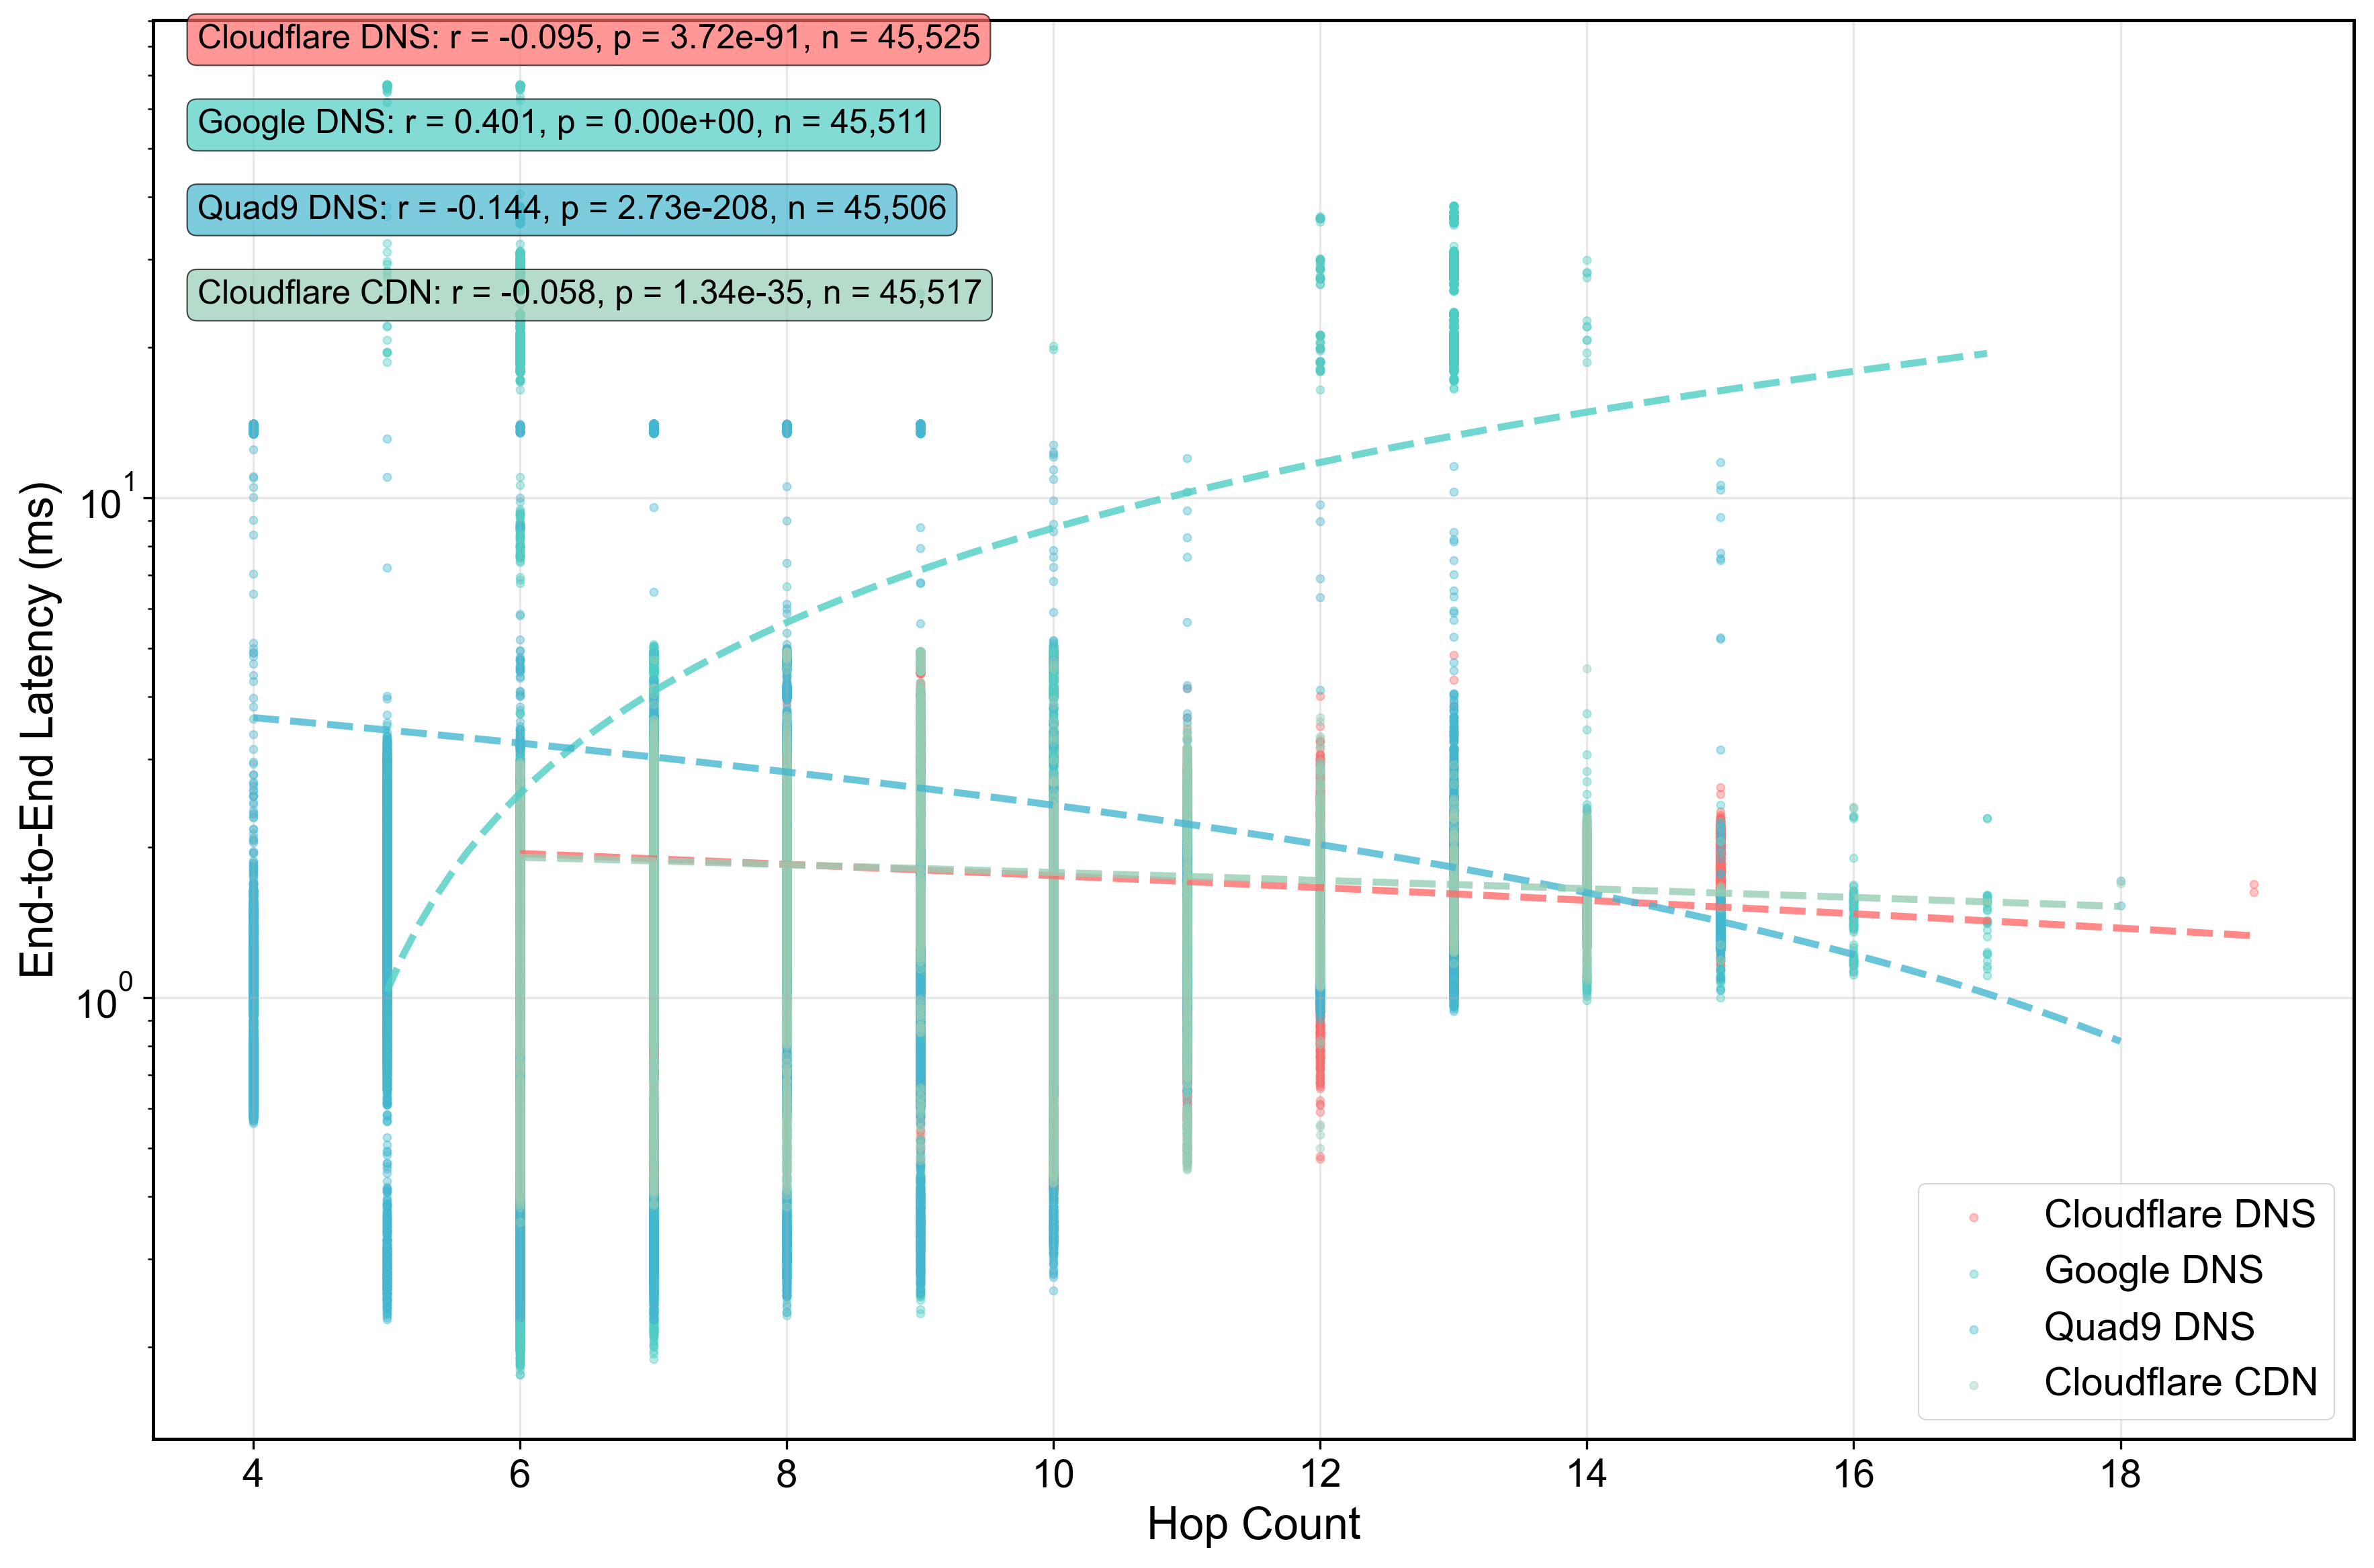

Creating Figure 2: Service Architecture Performance...


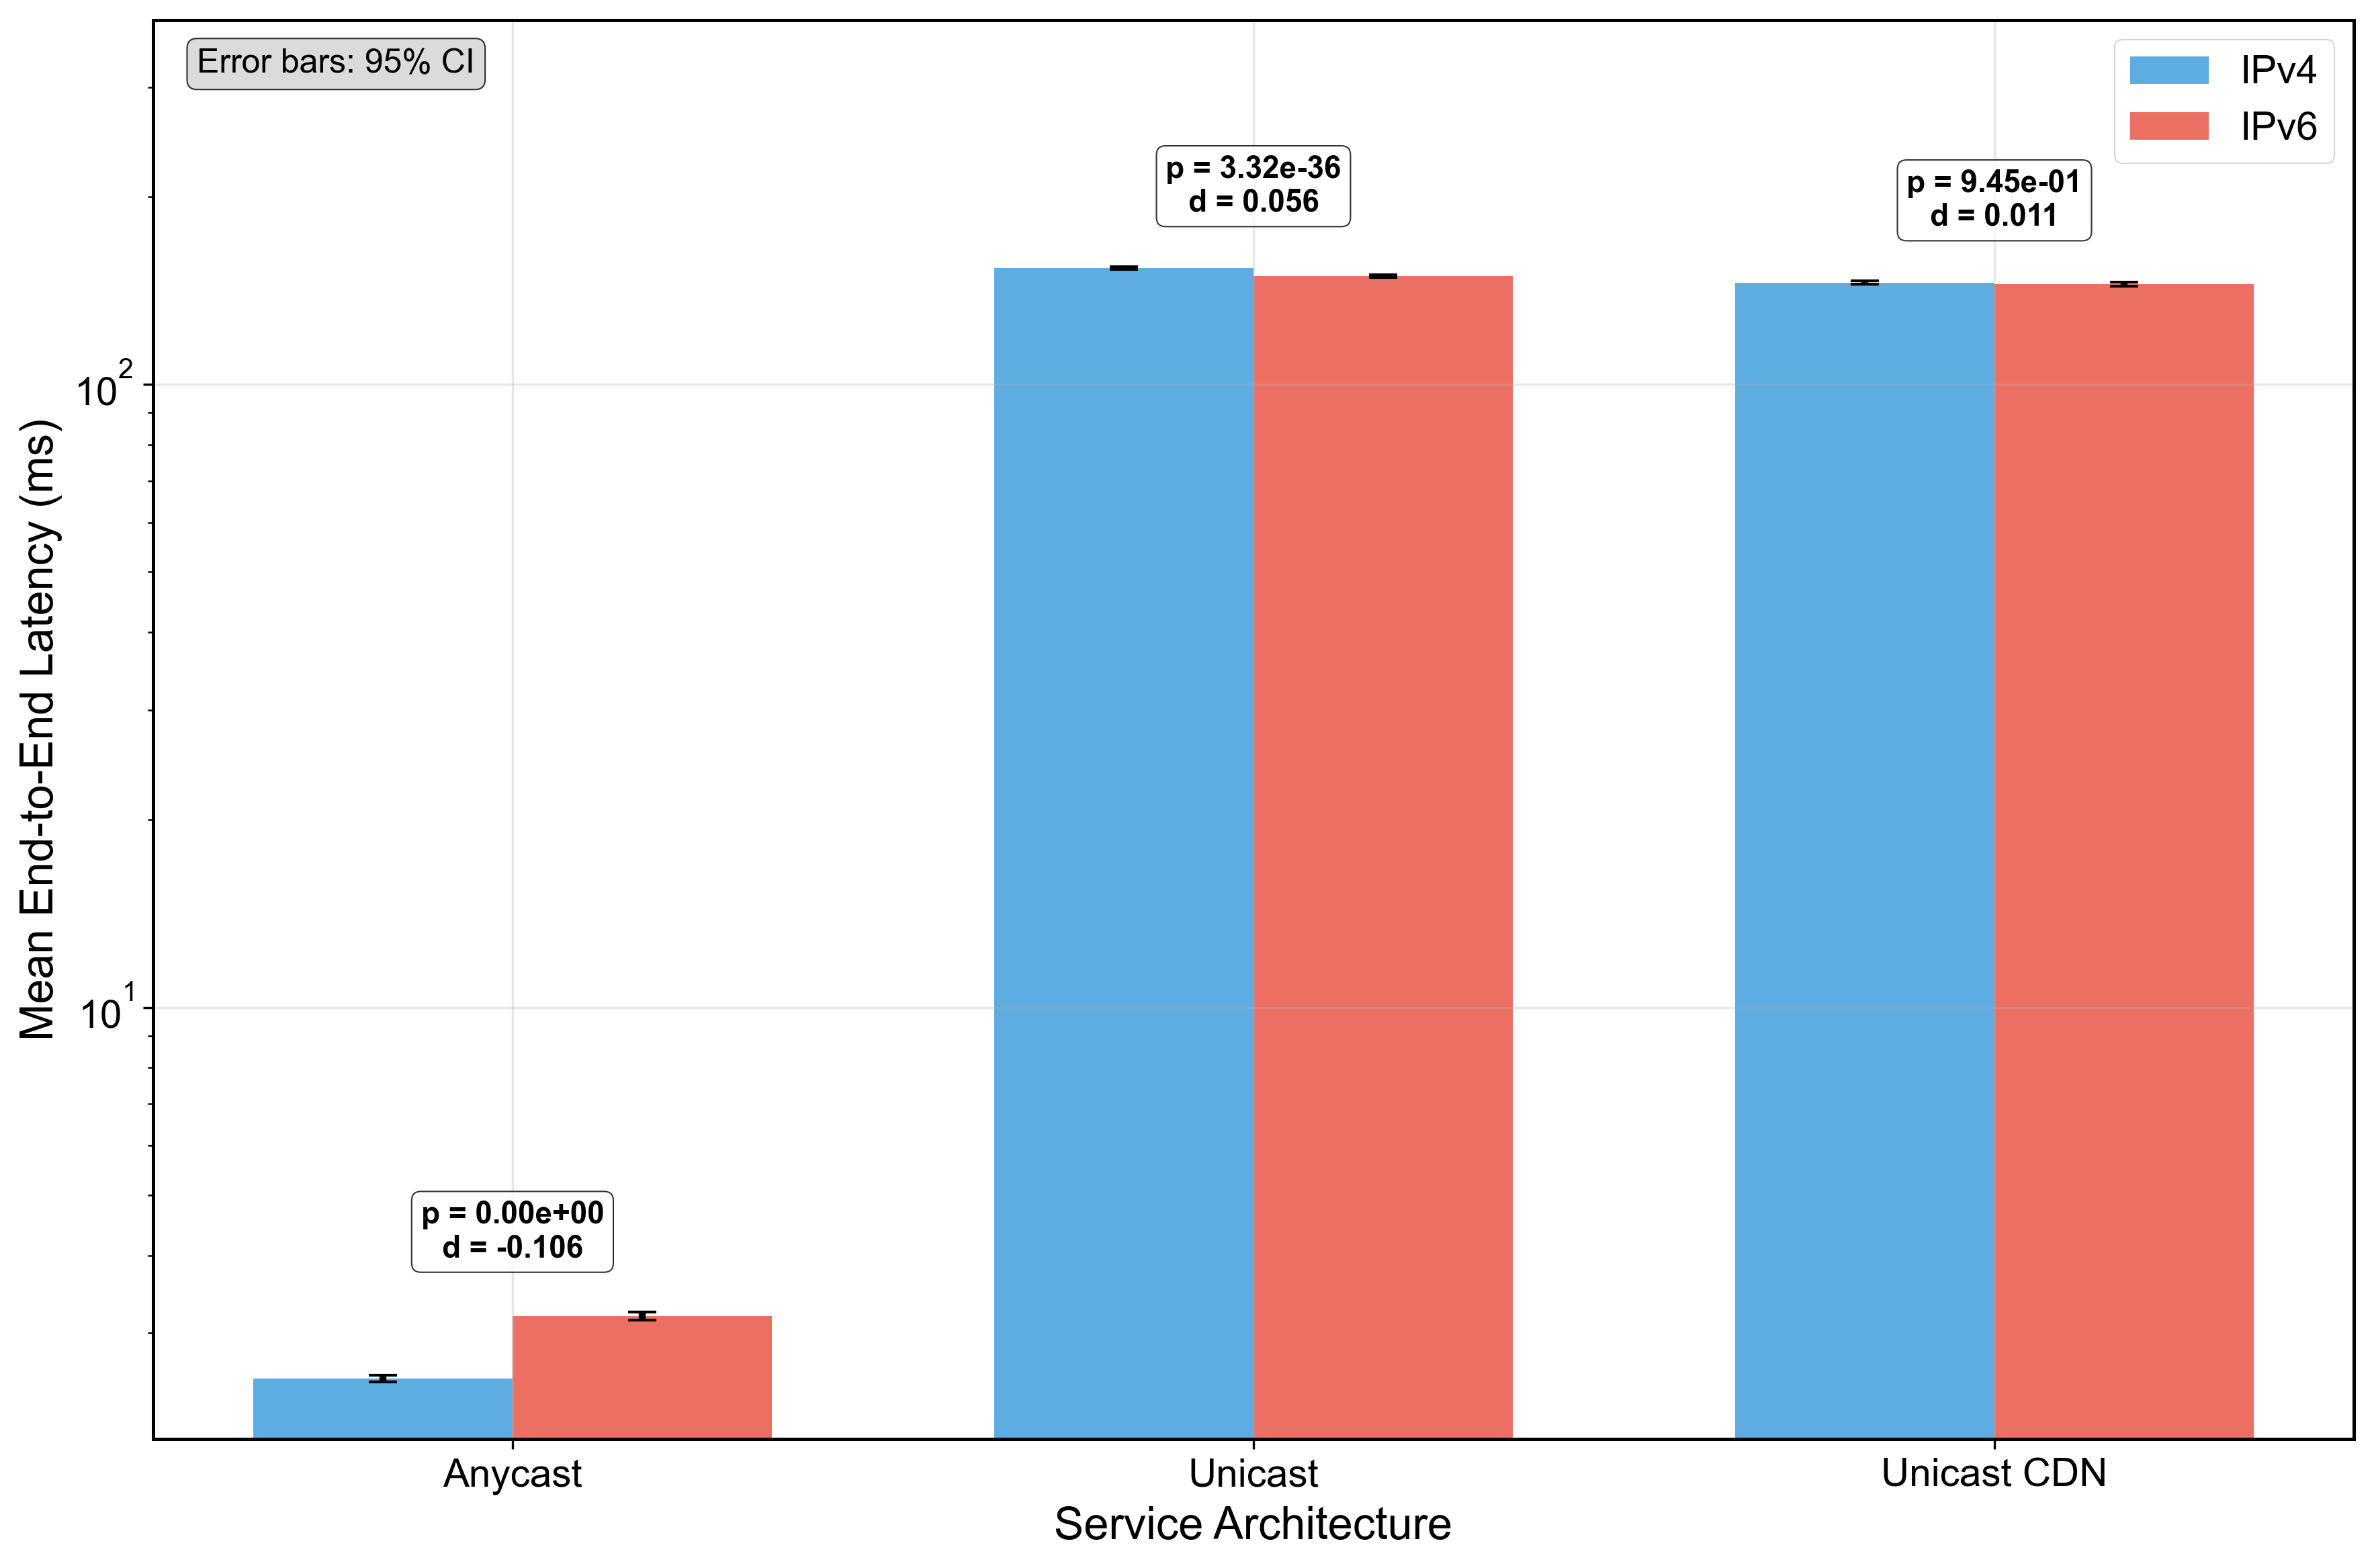

Creating Figure 3: Service Provider Performance...


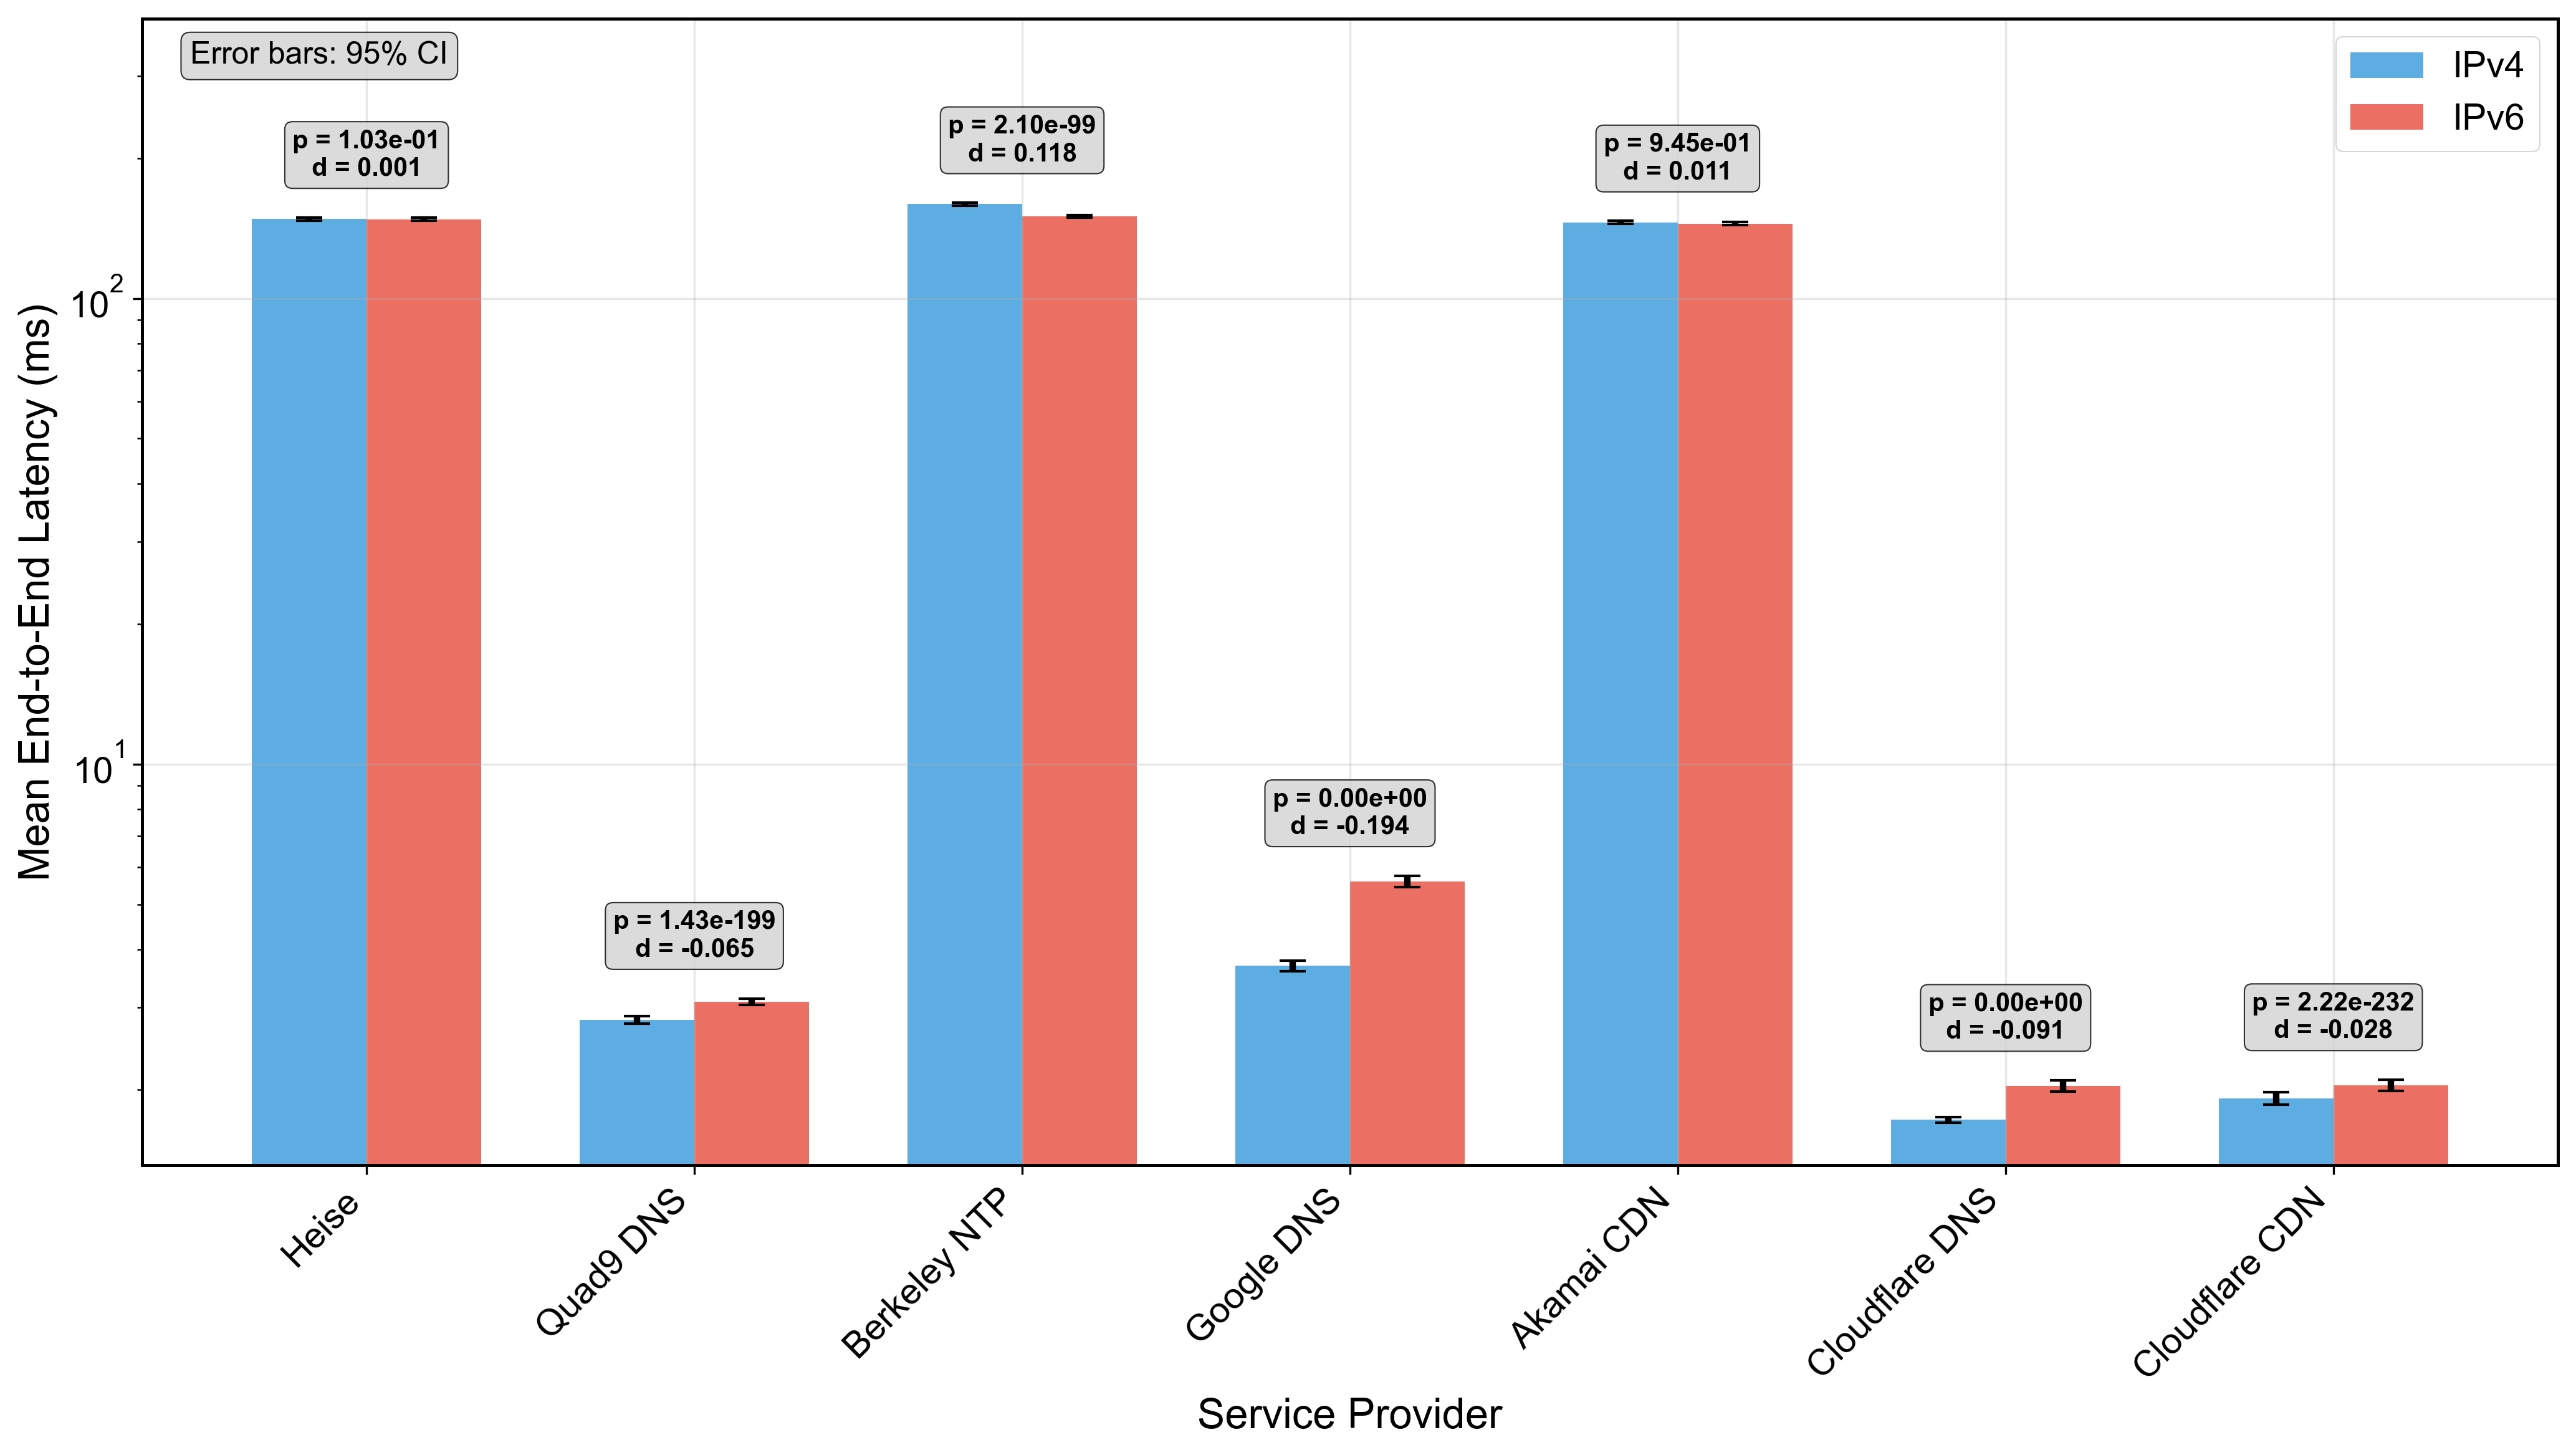

Creating Figure 4: Anycast Continental Performance...


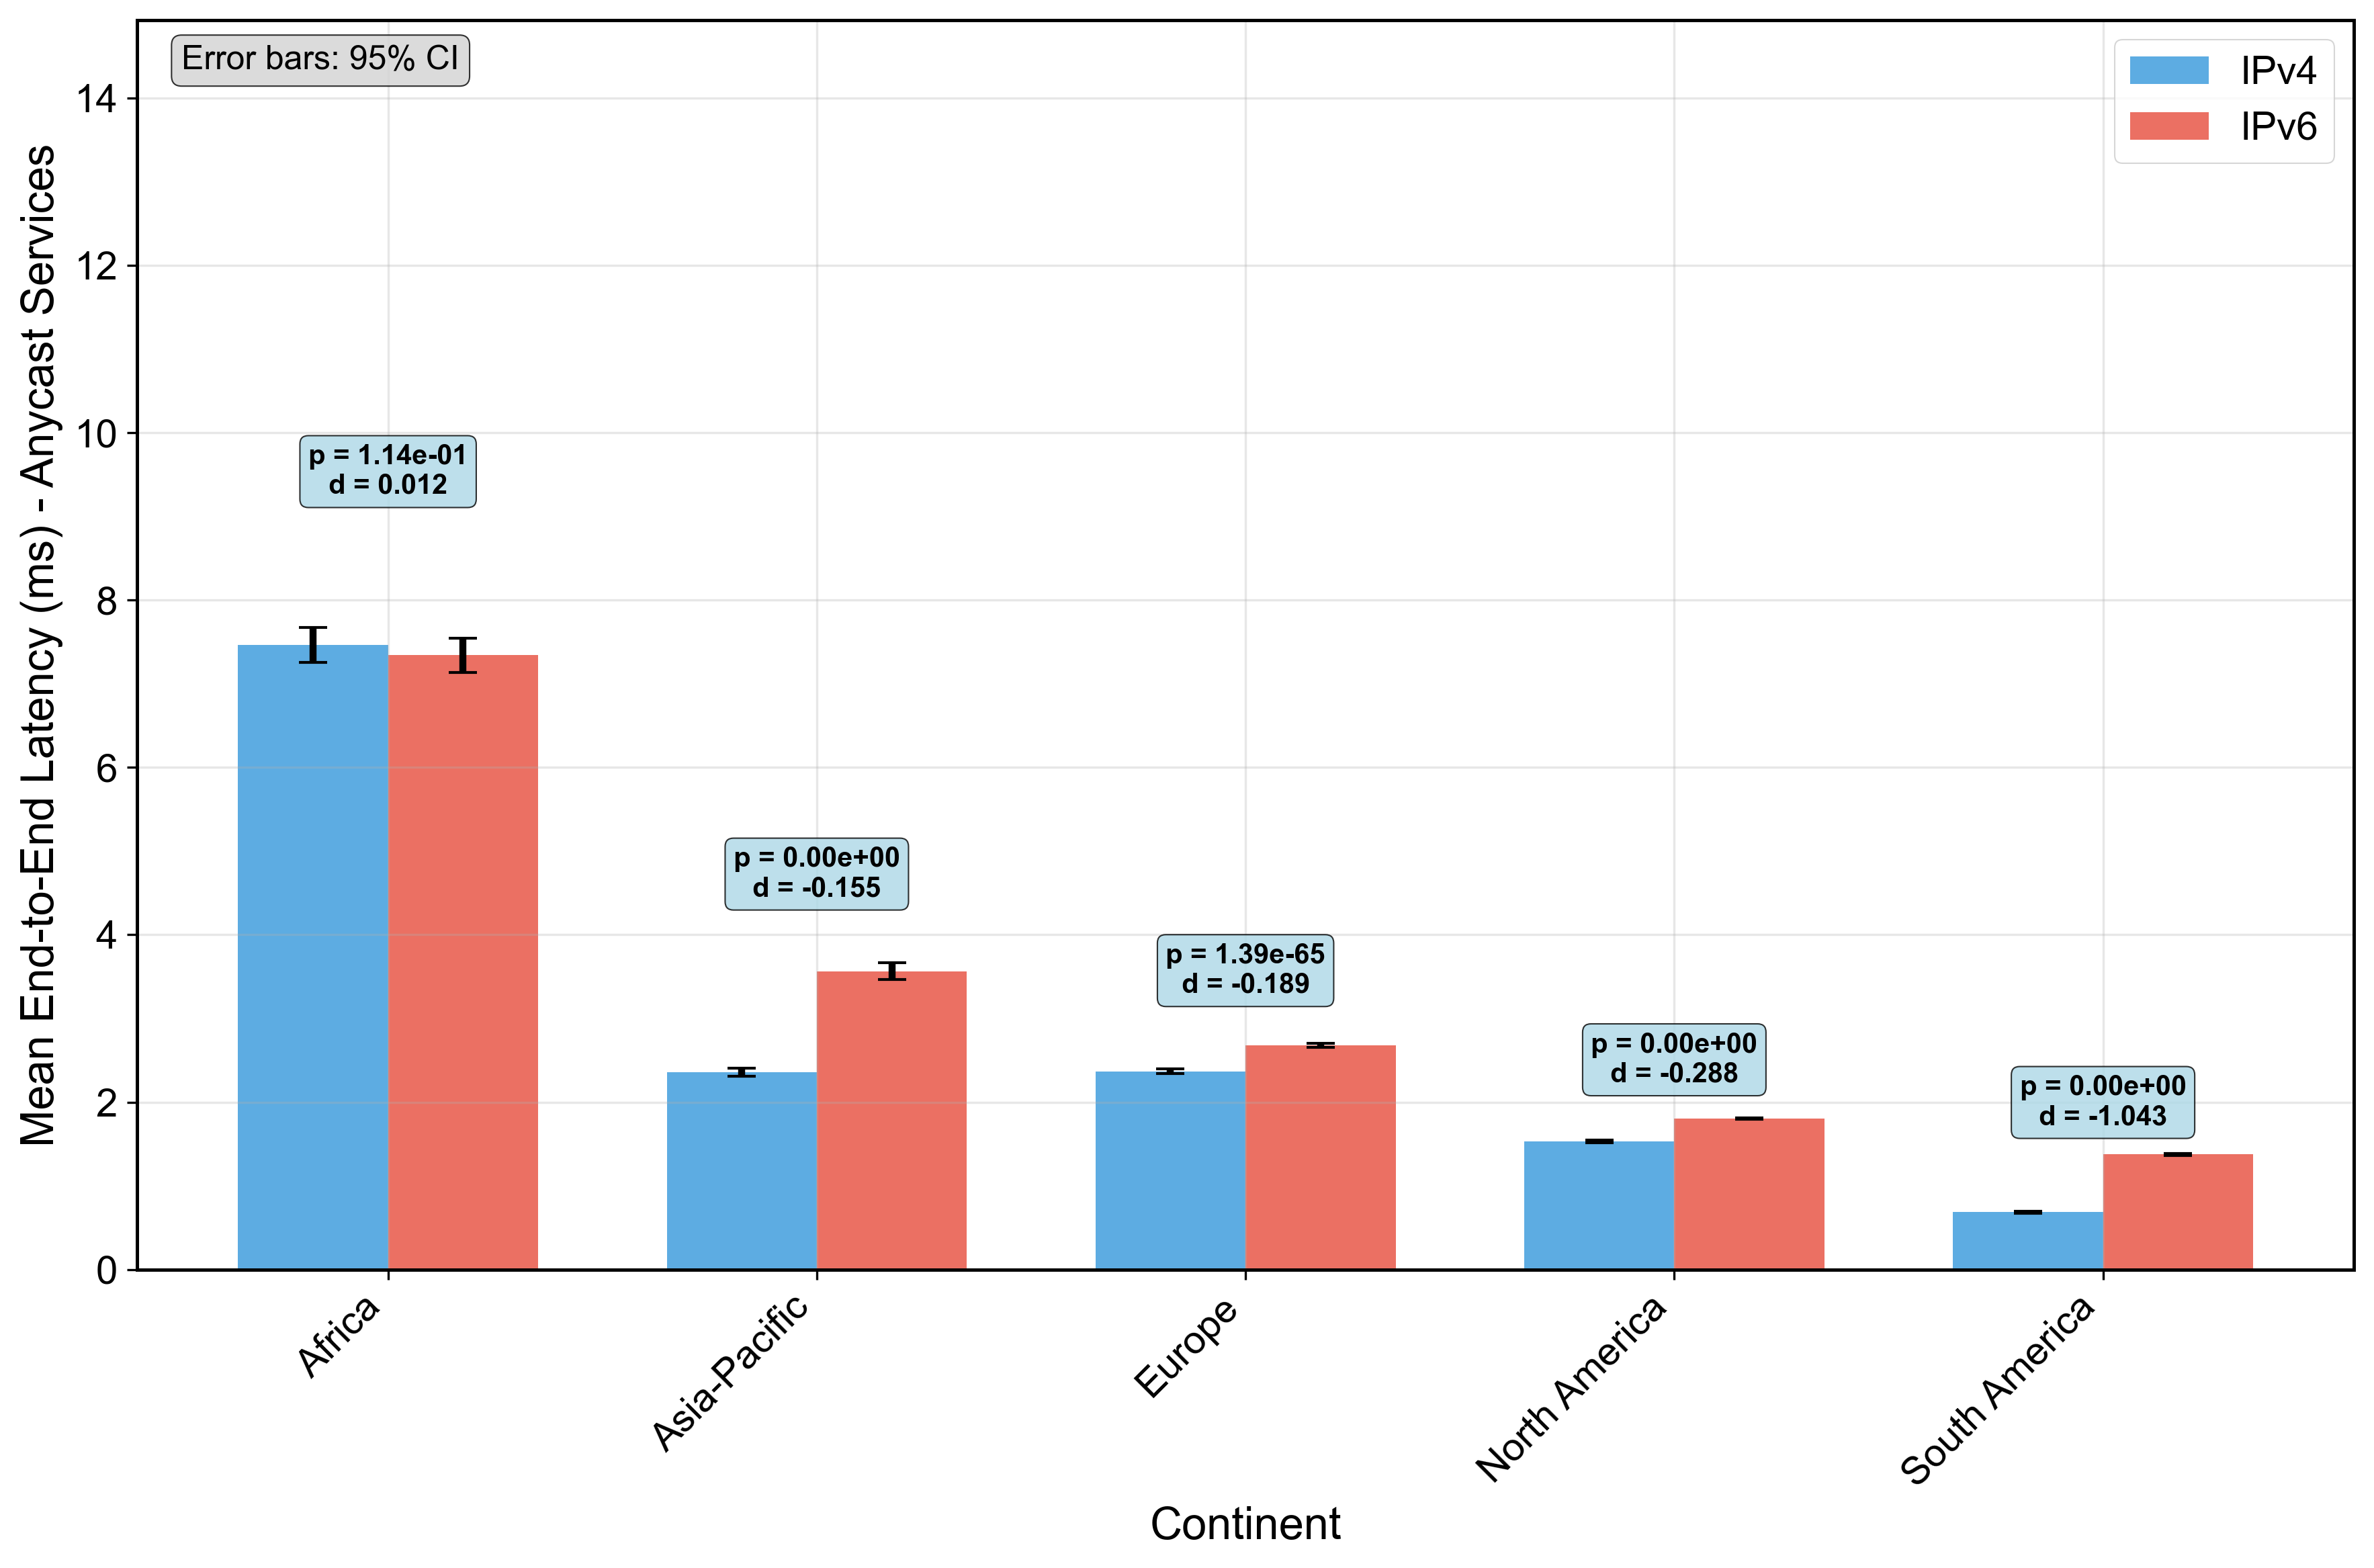

Creating Figure 5: Unicast Continental Performance...


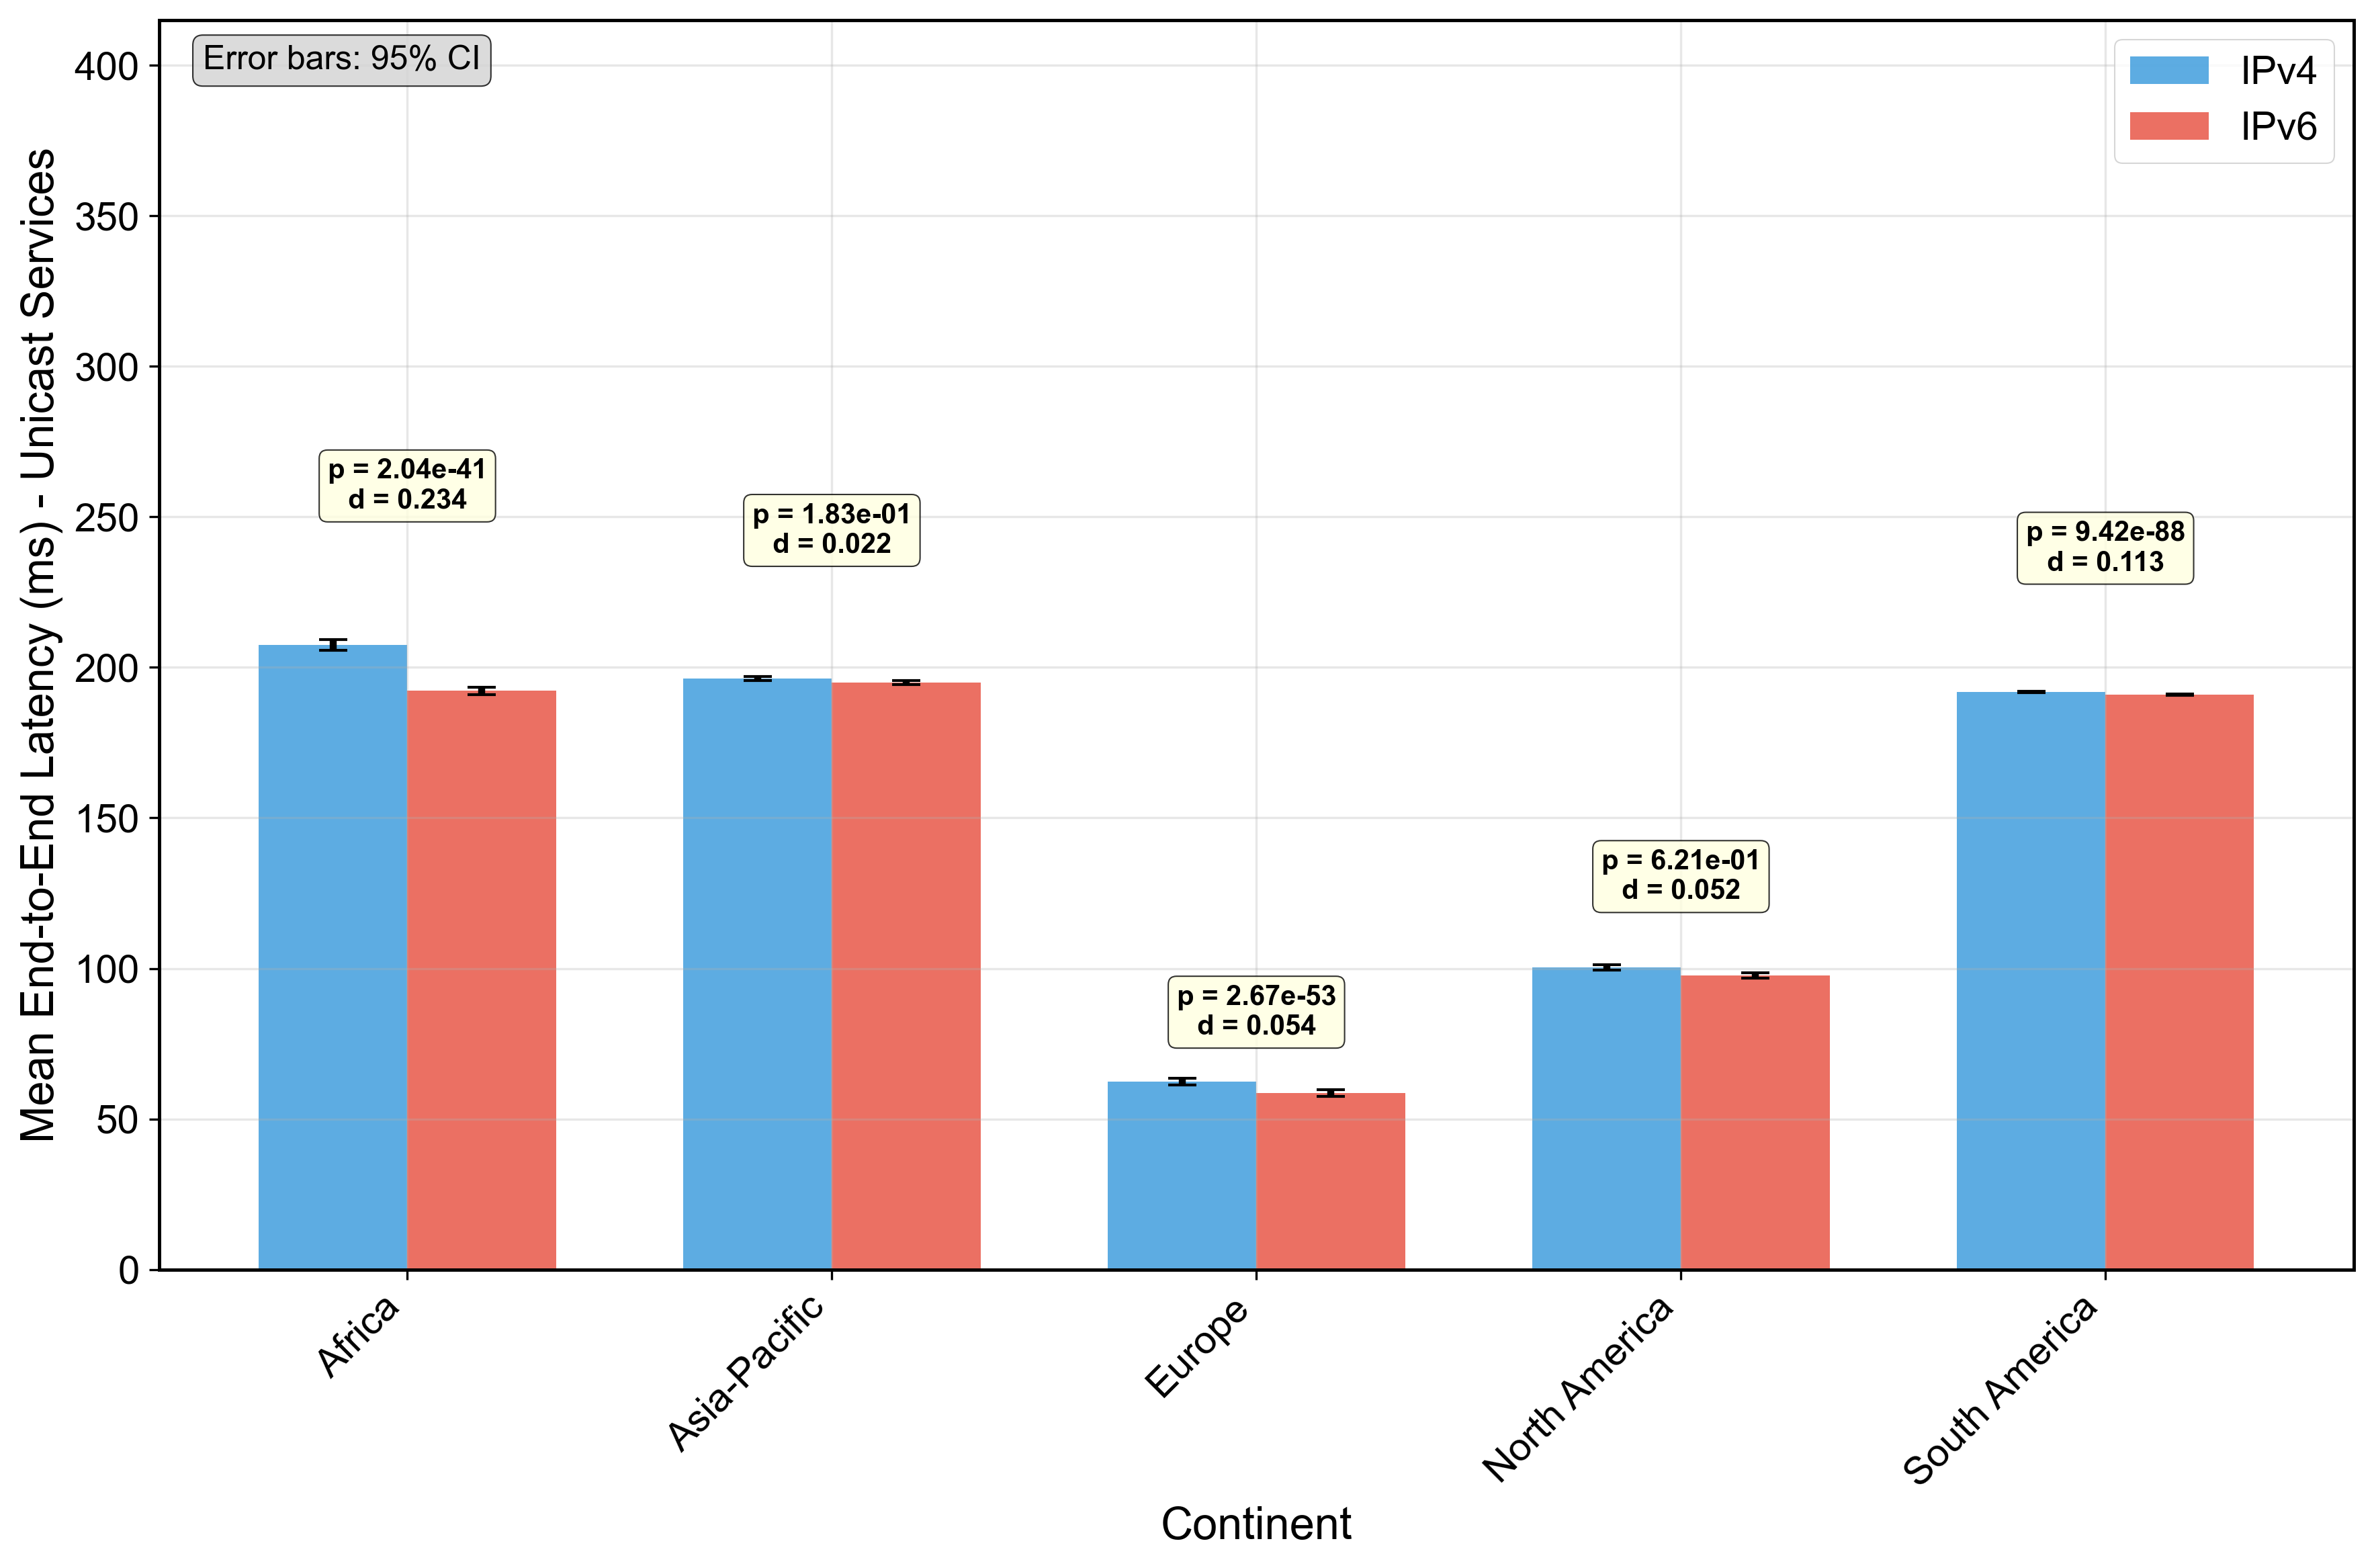


=== FIGURE GENERATION COMPLETE ===
Generated 5 single-panel publication-quality figures
All figures saved to ../results/ directory

Figures created:
  1. Figure 1: Anycast Latency Paradox
  2. Figure 2: Service Architecture Performance
  3. Figure 3: Service Provider Performance
  4. Figure 4: Anycast Continental Performance
  5. Figure 5: Unicast Continental Performance


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu, pearsonr
import warnings
warnings.filterwarnings('ignore')

# Set up publication-quality plotting style
plt.style.use('default')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans', 'Liberation Sans'],
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 0,  # No titles as requested
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'figure.figsize': (12, 8),
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.format': 'png',
    'axes.linewidth': 1.2,
    'grid.linewidth': 0.8,
    'lines.linewidth': 2.5,
    'patch.linewidth': 0.5,
    'axes.grid': True,
    'grid.alpha': 0.3
})

# Set colorful palette for publication
colors = {
    'Cloudflare DNS': '#FF6B6B',     # Coral red
    'Google DNS': '#4ECDC4',         # Teal
    'Quad9 DNS': '#45B7D1',          # Sky blue  
    'Cloudflare CDN': '#96CEB4',     # Mint green
    'Akamai CDN': '#FFEAA7',         # Light yellow
    'Heise': '#DDA0DD',              # Plum
    'Berkeley NTP': '#F39C12',       # Orange
    'IPv4': '#3498DB',               # Blue
    'IPv6': '#E74C3C',               # Red
    'Anycast': '#2ECC71',            # Green
    'Unicast': '#E67E22',            # Orange
    'Unicast CDN': '#9B59B6'         # Purple
}

def calculate_cohens_d(group1, group2):
    """Calculate Cohen's d effect size"""
    n1, n2 = len(group1), len(group2)
    pooled_std = np.sqrt(((n1 - 1) * group1.std() ** 2 + (n2 - 1) * group2.std() ** 2) / (n1 + n2 - 2))
    return (group1.mean() - group2.mean()) / pooled_std

def load_data():
    """Load and prepare all necessary data"""
    print("Loading data files...")
    
    # Load raw parquet files
    df_ipv4 = pd.read_parquet("../data/IPv4.parquet")
    df_ipv6 = pd.read_parquet("../data/IPv6.parquet")
    
    # Service mappings
    service_mapping = {
        '1.1.1.1': 'Cloudflare DNS', '8.8.8.8': 'Google DNS', '9.9.9.9': 'Quad9 DNS',
        '2.16.241.219': 'Akamai CDN', '104.16.123.96': 'Cloudflare CDN',
        '193.99.144.85': 'Heise', '169.229.128.134': 'Berkeley NTP',
        '2606:4700:4700::1111': 'Cloudflare DNS', '2001:4860:4860::8888': 'Google DNS',
        '2620:fe::fe:9': 'Quad9 DNS', '2a02:26f0:3500:1b::1724:a393': 'Akamai CDN',
        '2606:4700::6810:7b60': 'Cloudflare CDN', '2a02:2e0:3fe:1001:7777:772e:2:85': 'Heise',
        '2607:f140:ffff:8000:0:8006:0:a': 'Berkeley NTP'
    }
    
    service_type_mapping = {
        'Cloudflare DNS': 'Anycast', 'Google DNS': 'Anycast', 'Quad9 DNS': 'Anycast',
        'Cloudflare CDN': 'Anycast', 'Akamai CDN': 'Unicast CDN', 
        'Heise': 'Unicast', 'Berkeley NTP': 'Unicast'
    }
    
    # Add service columns
    for df in [df_ipv4, df_ipv6]:
        df['service_provider'] = df['dst'].map(service_mapping)
        df['service_type'] = df['service_provider'].map(service_type_mapping)
        df['utctime'] = pd.to_datetime(df['utctime'])
    
    df_ipv4['protocol'] = 'IPv4'
    df_ipv6['protocol'] = 'IPv6'
    
    # Try to load processed results, if available
    try:
        latency_data = pd.read_csv('../results/latency_analysis.csv')
        latency_data['timestamp'] = pd.to_datetime(latency_data['timestamp'])
        print("✓ Loaded processed latency analysis")
    except:
        print("⚠ Processed latency data not found, will extract from raw data")
        latency_data = None
    
    return df_ipv4, df_ipv6, latency_data, service_mapping, service_type_mapping

def extract_measurement_data(df_ipv4, df_ipv6):
    """Extract latency and hop count data from raw parquet files"""
    print("Extracting measurement data from raw files...")
    
    all_measurements = []
    
    for df, protocol in [(df_ipv4, 'IPv4'), (df_ipv6, 'IPv6')]:
        for _, row in df.iterrows():
            hubs = row['hubs']
            if hubs is not None and len(hubs) > 0:
                # Extract final hop latency
                final_hop = hubs[-1]
                end_latency = final_hop.get('Avg', 0) if final_hop.get('Avg') is not None else 0
                
                # Calculate additional metrics
                all_latencies = [hop.get('Avg', 0) for hop in hubs if hop.get('Avg') is not None and hop.get('Avg') > 0]
                all_jitter = [hop.get('Javg', 0) for hop in hubs if hop.get('Javg') is not None and hop.get('Javg') > 0]
                all_loss = [hop.get('Loss%', 0) for hop in hubs if hop.get('Loss%') is not None]
                
                measurement = {
                    'protocol': protocol,
                    'region': row['region'],
                    'service_provider': row['service_provider'],
                    'service_type': row['service_type'],
                    'timestamp': row['utctime'],
                    'hop_count': len(hubs),
                    'end_to_end_latency': end_latency,
                    'path_avg_latency': np.mean(all_latencies) if all_latencies else 0,
                    'path_avg_jitter': np.mean(all_jitter) if all_jitter else 0,
                    'path_avg_loss': np.mean(all_loss) if all_loss else 0,
                    'latency_per_hop': end_latency / len(hubs) if len(hubs) > 0 else 0,
                    'measurement_id': row['id']
                }
                all_measurements.append(measurement)
    
    return pd.DataFrame(all_measurements)

def create_anycast_paradox_figure(data):
    """Create Figure 1: The Anycast Latency Paradox"""
    print("Creating Figure 1: Anycast Latency Paradox...")
    
    # Filter anycast services only
    anycast_data = data[data['service_type'] == 'Anycast'].copy()
    
    # Remove extreme outliers (99th percentile)
    for service in anycast_data['service_provider'].unique():
        if pd.isna(service):
            continue
        service_data = anycast_data[anycast_data['service_provider'] == service]
        q99 = service_data['end_to_end_latency'].quantile(0.99)
        anycast_data = anycast_data[
            ~((anycast_data['service_provider'] == service) & 
              (anycast_data['end_to_end_latency'] > q99))
        ]
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Plot each service provider
    services = ['Cloudflare DNS', 'Google DNS', 'Quad9 DNS', 'Cloudflare CDN']
    
    for service in services:
        if service not in anycast_data['service_provider'].values:
            continue
            
        service_data = anycast_data[anycast_data['service_provider'] == service]
        
        if len(service_data) == 0:
            continue
        
        # Scatter plot
        ax.scatter(service_data['hop_count'], service_data['end_to_end_latency'], 
                  alpha=0.4, s=8, color=colors[service], label=service)
        
        # Calculate correlation
        if len(service_data) > 10:
            corr, p_val = pearsonr(service_data['hop_count'], service_data['end_to_end_latency'])
            
            # Add trend line
            z = np.polyfit(service_data['hop_count'], service_data['end_to_end_latency'], 1)
            p = np.poly1d(z)
            x_line = np.linspace(service_data['hop_count'].min(), service_data['hop_count'].max(), 100)
            ax.plot(x_line, p(x_line), color=colors[service], linewidth=2.5, alpha=0.8, linestyle='--')
            
            # Add correlation text with exact p-values
            ax.text(0.02, 0.98 - services.index(service)*0.06, 
                   f'{service}: r = {corr:.3f}, p = {p_val:.2e}, n = {len(service_data):,}',
                   transform=ax.transAxes, fontsize=12, 
                   bbox=dict(boxstyle='round,pad=0.3', facecolor=colors[service], alpha=0.7))
    
    ax.set_xlabel('Hop Count', fontsize=16)
    ax.set_ylabel('End-to-End Latency (ms)', fontsize=16)
    ax.set_yscale('log')
    ax.legend(loc='lower right', fontsize=14)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../results/figure_1_anycast_paradox.png')
    plt.show()
    
    return fig

def create_service_type_comparison_figure(data):
    """Create Figure 2: Service Architecture Performance Comparison (Single Panel)"""
    print("Creating Figure 2: Service Architecture Performance...")
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Prepare data for comparison
    service_performance = data.groupby(['protocol', 'service_type'])['end_to_end_latency'].agg([
        'mean', 'std', 'count'
    ]).reset_index()
    
    service_performance['sem'] = service_performance['std'] / np.sqrt(service_performance['count'])
    service_performance['ci'] = 1.96 * service_performance['sem']  # 95% CI
    
    service_types = ['Anycast', 'Unicast', 'Unicast CDN']
    x = np.arange(len(service_types))
    width = 0.35
    
    ipv4_means = []
    ipv4_cis = []
    ipv6_means = []
    ipv6_cis = []
    
    for service_type in service_types:
        ipv4_row = service_performance[
            (service_performance['protocol'] == 'IPv4') & 
            (service_performance['service_type'] == service_type)
        ]
        ipv6_row = service_performance[
            (service_performance['protocol'] == 'IPv6') & 
            (service_performance['service_type'] == service_type)
        ]
        
        ipv4_means.append(ipv4_row['mean'].iloc[0] if len(ipv4_row) > 0 else 0)
        ipv4_cis.append(ipv4_row['ci'].iloc[0] if len(ipv4_row) > 0 else 0)
        ipv6_means.append(ipv6_row['mean'].iloc[0] if len(ipv6_row) > 0 else 0)
        ipv6_cis.append(ipv6_row['ci'].iloc[0] if len(ipv6_row) > 0 else 0)
    
    bars1 = ax.bar(x - width/2, ipv4_means, width, label='IPv4', 
                   color=colors['IPv4'], alpha=0.8, yerr=ipv4_cis, capsize=5)
    bars2 = ax.bar(x + width/2, ipv6_means, width, label='IPv6', 
                   color=colors['IPv6'], alpha=0.8, yerr=ipv6_cis, capsize=5)
    
    ax.set_xlabel('Service Architecture', fontsize=16)
    ax.set_ylabel('Mean End-to-End Latency (ms)', fontsize=16)
    ax.set_xticks(x)
    ax.set_xticklabels(service_types)
    ax.legend(fontsize=14)
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    
    # Add statistical annotations with exact p-values and Cohen's d
    max_y = max(max(ipv4_means), max(ipv6_means)) * 2.5  # Set reasonable upper limit
    for i, service_type in enumerate(service_types):
        ipv4_data = data[(data['protocol'] == 'IPv4') & (data['service_type'] == service_type)]['end_to_end_latency']
        ipv6_data = data[(data['protocol'] == 'IPv6') & (data['service_type'] == service_type)]['end_to_end_latency']
        
        if len(ipv4_data) > 0 and len(ipv6_data) > 0:
            stat, p_val = mannwhitneyu(ipv4_data, ipv6_data, alternative='two-sided')
            cohens_d = calculate_cohens_d(ipv4_data, ipv6_data)
            
            # Position annotations within figure bounds
            y_pos = min(max(ipv4_means[i] + ipv4_cis[i], ipv6_means[i] + ipv6_cis[i]) * 1.2, max_y * 0.8)
            ax.text(i, y_pos, f'p = {p_val:.2e}\nd = {cohens_d:.3f}', 
                   ha='center', va='bottom', fontsize=11, fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    
    # Add error bar explanation
    ax.text(0.02, 0.98, 'Error bars: 95% CI', transform=ax.transAxes, 
            fontsize=12, va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgray', alpha=0.8))
    
    # Adjust y-axis limits to accommodate annotations
    ax.set_ylim(bottom=min(min(ipv4_means), min(ipv6_means)) * 0.8, top=max_y)
    
    plt.tight_layout()
    plt.savefig('../results/figure_2_service_architecture_comparison.png')
    plt.show()
    
    return fig

def create_provider_performance_figure(data):
    """Create Figure 3: Individual Service Provider Performance (Single Panel)"""
    print("Creating Figure 3: Service Provider Performance...")
    
    fig, ax = plt.subplots(figsize=(14, 8))
    
    provider_performance = data.groupby(['protocol', 'service_provider'])['end_to_end_latency'].agg([
        'mean', 'std', 'count'
    ]).reset_index()
    
    provider_performance['sem'] = provider_performance['std'] / np.sqrt(provider_performance['count'])
    provider_performance['ci'] = 1.96 * provider_performance['sem']
    
    providers = data['service_provider'].unique()
    providers = [p for p in providers if pd.notna(p)]
    x = np.arange(len(providers))
    width = 0.35
    
    ipv4_means = []
    ipv4_cis = []
    ipv6_means = []
    ipv6_cis = []
    
    for provider in providers:
        ipv4_row = provider_performance[
            (provider_performance['protocol'] == 'IPv4') & 
            (provider_performance['service_provider'] == provider)
        ]
        ipv6_row = provider_performance[
            (provider_performance['protocol'] == 'IPv6') & 
            (provider_performance['service_provider'] == provider)
        ]
        
        ipv4_means.append(ipv4_row['mean'].iloc[0] if len(ipv4_row) > 0 else 0)
        ipv4_cis.append(ipv4_row['ci'].iloc[0] if len(ipv4_row) > 0 else 0)
        ipv6_means.append(ipv6_row['mean'].iloc[0] if len(ipv6_row) > 0 else 0)
        ipv6_cis.append(ipv6_row['ci'].iloc[0] if len(ipv6_row) > 0 else 0)
    
    ax.bar(x - width/2, ipv4_means, width, label='IPv4', 
           color=colors['IPv4'], alpha=0.8, yerr=ipv4_cis, capsize=5)
    ax.bar(x + width/2, ipv6_means, width, label='IPv6', 
           color=colors['IPv6'], alpha=0.8, yerr=ipv6_cis, capsize=5)
    
    ax.set_xlabel('Service Provider', fontsize=16)
    ax.set_ylabel('Mean End-to-End Latency (ms)', fontsize=16)
    ax.set_xticks(x)
    ax.set_xticklabels(providers, rotation=45, ha='right')
    ax.legend(fontsize=14)
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    
    # Add statistical annotations for all comparisons
    max_y = max(max(ipv4_means), max(ipv6_means)) * 2.5
    for i, provider in enumerate(providers):
        ipv4_data = data[(data['protocol'] == 'IPv4') & (data['service_provider'] == provider)]['end_to_end_latency']
        ipv6_data = data[(data['protocol'] == 'IPv6') & (data['service_provider'] == provider)]['end_to_end_latency']
        
        if len(ipv4_data) > 0 and len(ipv6_data) > 0:
            stat, p_val = mannwhitneyu(ipv4_data, ipv6_data, alternative='two-sided')
            cohens_d = calculate_cohens_d(ipv4_data, ipv6_data)
            
            # Position annotations within figure bounds
            y_pos = min(max(ipv4_means[i] + ipv4_cis[i], ipv6_means[i] + ipv6_cis[i]) * 1.2, max_y * 0.8)
            ax.text(i, y_pos, f'p = {p_val:.2e}\nd = {cohens_d:.3f}', 
                   ha='center', va='bottom', fontsize=10, fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgray', alpha=0.8))
    
    # Add error bar explanation
    ax.text(0.02, 0.98, 'Error bars: 95% CI', transform=ax.transAxes, 
            fontsize=12, va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgray', alpha=0.8))
    
    # Adjust y-axis limits
    ax.set_ylim(bottom=min(min(ipv4_means), min(ipv6_means)) * 0.8, top=max_y)
    
    plt.tight_layout()
    plt.savefig('../results/figure_3_provider_performance.png')
    plt.show()
    
    return fig

def create_anycast_continental_figure(data):
    """Create Figure 4: Anycast Continental Performance (Single Panel)"""
    print("Creating Figure 4: Anycast Continental Performance...")
    
    # Regional mapping
    region_to_continent = {
        'us-west-1': 'North America', 'ca-central-1': 'North America', 
        'eu-central-1': 'Europe', 'eu-north-1': 'Europe', 'af-south-1': 'Africa',
        'ap-east-1': 'Asia-Pacific', 'ap-south-1': 'Asia-Pacific', 
        'ap-northeast-1': 'Asia-Pacific', 'ap-southeast-2': 'Asia-Pacific',
        'sa-east-1': 'South America'
    }
    
    data['continent'] = data['region'].map(region_to_continent)
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Filter anycast services only
    anycast_data = data[data['service_type'] == 'Anycast']
    anycast_continental = anycast_data.groupby(['continent', 'protocol'])['end_to_end_latency'].agg([
        'mean', 'std', 'count'
    ]).reset_index()
    
    anycast_continental['sem'] = anycast_continental['std'] / np.sqrt(anycast_continental['count'])
    anycast_continental['ci'] = 1.96 * anycast_continental['sem']
    
    continents = sorted(anycast_continental['continent'].unique())
    x = np.arange(len(continents))
    width = 0.35
    
    ipv4_means = []
    ipv4_cis = []
    ipv6_means = []
    ipv6_cis = []
    
    for continent in continents:
        ipv4_row = anycast_continental[
            (anycast_continental['continent'] == continent) & 
            (anycast_continental['protocol'] == 'IPv4')
        ]
        ipv6_row = anycast_continental[
            (anycast_continental['continent'] == continent) & 
            (anycast_continental['protocol'] == 'IPv6')
        ]
        
        ipv4_means.append(ipv4_row['mean'].iloc[0] if len(ipv4_row) > 0 else 0)
        ipv4_cis.append(ipv4_row['ci'].iloc[0] if len(ipv4_row) > 0 else 0)
        ipv6_means.append(ipv6_row['mean'].iloc[0] if len(ipv6_row) > 0 else 0)
        ipv6_cis.append(ipv6_row['ci'].iloc[0] if len(ipv6_row) > 0 else 0)
    
    ax.bar(x - width/2, ipv4_means, width, label='IPv4', 
           color=colors['IPv4'], alpha=0.8, yerr=ipv4_cis, capsize=5)
    ax.bar(x + width/2, ipv6_means, width, label='IPv6', 
           color=colors['IPv6'], alpha=0.8, yerr=ipv6_cis, capsize=5)
    
    ax.set_xlabel('Continent', fontsize=16)
    ax.set_ylabel('Mean End-to-End Latency (ms) - Anycast Services', fontsize=16)
    ax.set_xticks(x)
    ax.set_xticklabels(continents, rotation=45, ha='right')
    ax.legend(fontsize=14)
    ax.grid(True, alpha=0.3)
    
    # Add statistical annotations
    max_y = max(max(ipv4_means), max(ipv6_means)) * 2.0
    for i, continent in enumerate(continents):
        ipv4_data = anycast_data[(anycast_data['continent'] == continent) & (anycast_data['protocol'] == 'IPv4')]['end_to_end_latency']
        ipv6_data = anycast_data[(anycast_data['continent'] == continent) & (anycast_data['protocol'] == 'IPv6')]['end_to_end_latency']
        
        if len(ipv4_data) > 0 and len(ipv6_data) > 0:
            stat, p_val = mannwhitneyu(ipv4_data, ipv6_data, alternative='two-sided')
            cohens_d = calculate_cohens_d(ipv4_data, ipv6_data)
            
            # Position annotations within figure bounds
            y_pos = min(max(ipv4_means[i] + ipv4_cis[i], ipv6_means[i] + ipv6_cis[i]) * 1.2, max_y * 0.8)
            ax.text(i, y_pos, f'p = {p_val:.2e}\nd = {cohens_d:.3f}', 
                   ha='center', va='bottom', fontsize=10, fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='lightblue', alpha=0.8))
    
    # Add error bar explanation
    ax.text(0.02, 0.98, 'Error bars: 95% CI', transform=ax.transAxes, 
            fontsize=12, va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgray', alpha=0.8))
    
    # Adjust y-axis limits
    ax.set_ylim(bottom=0, top=max_y)
    
    plt.tight_layout()
    plt.savefig('../results/figure_4_anycast_continental.png')
    plt.show()
    
    return fig

def create_unicast_continental_figure(data):
    """Create Figure 5: Unicast Continental Performance (Single Panel)"""
    print("Creating Figure 5: Unicast Continental Performance...")
    
    # Regional mapping
    region_to_continent = {
        'us-west-1': 'North America', 'ca-central-1': 'North America', 
        'eu-central-1': 'Europe', 'eu-north-1': 'Europe', 'af-south-1': 'Africa',
        'ap-east-1': 'Asia-Pacific', 'ap-south-1': 'Asia-Pacific', 
        'ap-northeast-1': 'Asia-Pacific', 'ap-southeast-2': 'Asia-Pacific',
        'sa-east-1': 'South America'
    }
    
    data['continent'] = data['region'].map(region_to_continent)
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Filter unicast services only
    unicast_data = data[data['service_type'].isin(['Unicast', 'Unicast CDN'])]
    unicast_continental = unicast_data.groupby(['continent', 'protocol'])['end_to_end_latency'].agg([
        'mean', 'std', 'count'
    ]).reset_index()
    
    unicast_continental['sem'] = unicast_continental['std'] / np.sqrt(unicast_continental['count'])
    unicast_continental['ci'] = 1.96 * unicast_continental['sem']
    
    continents = sorted(unicast_continental['continent'].unique())
    x = np.arange(len(continents))
    width = 0.35
    
    ipv4_means = []
    ipv4_cis = []
    ipv6_means = []
    ipv6_cis = []
    
    for continent in continents:
        ipv4_row = unicast_continental[
            (unicast_continental['continent'] == continent) & 
            (unicast_continental['protocol'] == 'IPv4')
        ]
        ipv6_row = unicast_continental[
            (unicast_continental['continent'] == continent) & 
            (unicast_continental['protocol'] == 'IPv6')
        ]
        
        ipv4_means.append(ipv4_row['mean'].iloc[0] if len(ipv4_row) > 0 else 0)
        ipv4_cis.append(ipv4_row['ci'].iloc[0] if len(ipv4_row) > 0 else 0)
        ipv6_means.append(ipv6_row['mean'].iloc[0] if len(ipv6_row) > 0 else 0)
        ipv6_cis.append(ipv6_row['ci'].iloc[0] if len(ipv6_row) > 0 else 0)
    
    ax.bar(x - width/2, ipv4_means, width, label='IPv4', 
           color=colors['IPv4'], alpha=0.8, yerr=ipv4_cis, capsize=5)
    ax.bar(x + width/2, ipv6_means, width, label='IPv6', 
           color=colors['IPv6'], alpha=0.8, yerr=ipv6_cis, capsize=5)
    
    ax.set_xlabel('Continent', fontsize=16)
    ax.set_ylabel('Mean End-to-End Latency (ms) - Unicast Services', fontsize=16)
    ax.set_xticks(x)
    ax.set_xticklabels(continents, rotation=45, ha='right')
    ax.legend(fontsize=14)
    ax.grid(True, alpha=0.3)
    
    # Add statistical annotations
    max_y = max(max(ipv4_means), max(ipv6_means)) * 2.0
    for i, continent in enumerate(continents):
        ipv4_data = unicast_data[(unicast_data['continent'] == continent) & (unicast_data['protocol'] == 'IPv4')]['end_to_end_latency']
        ipv6_data = unicast_data[(unicast_data['continent'] == continent) & (unicast_data['protocol'] == 'IPv6')]['end_to_end_latency']
        
        if len(ipv4_data) > 0 and len(ipv6_data) > 0:
            stat, p_val = mannwhitneyu(ipv4_data, ipv6_data, alternative='two-sided')
            cohens_d = calculate_cohens_d(ipv4_data, ipv6_data)
            
            # Position annotations within figure bounds
            y_pos = min(max(ipv4_means[i] + ipv4_cis[i], ipv6_means[i] + ipv6_cis[i]) * 1.2, max_y * 0.8)
            ax.text(i, y_pos, f'p = {p_val:.2e}\nd = {cohens_d:.3f}', 
                   ha='center', va='bottom', fontsize=10, fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))
    
    # Add error bar explanation
    ax.text(0.02, 0.98, 'Error bars: 95% CI', transform=ax.transAxes, 
            fontsize=12, va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgray', alpha=0.8))
    
    # Adjust y-axis limits
    ax.set_ylim(bottom=0, top=max_y)
    
    plt.tight_layout()
    plt.savefig('../results/figure_5_unicast_continental.png')
    plt.show()
    
    return fig

def main():
    """Main execution function"""
    print("=== PUBLICATION FIGURE GENERATOR (SINGLE PANELS) ===")
    print()
    
    # Load data
    df_ipv4, df_ipv6, latency_data, service_mapping, service_type_mapping = load_data()
    
    # If processed data not available, extract from raw data
    if latency_data is None:
        latency_data = extract_measurement_data(df_ipv4, df_ipv6)
        print(f"✓ Extracted data for {len(latency_data):,} measurements")
    else:
        print(f"✓ Using processed data with {len(latency_data):,} measurements")
    
    # Remove any rows with missing essential data
    latency_data = latency_data.dropna(subset=['end_to_end_latency', 'hop_count', 'service_provider'])
    latency_data = latency_data[latency_data['end_to_end_latency'] > 0]
    latency_data = latency_data[latency_data['hop_count'] > 0]
    
    print(f"✓ Clean dataset: {len(latency_data):,} measurements ready for analysis")
    print()
    
    # Generate figures (all single panels now)
    figures = []
    
    # Figure 1: Anycast Latency Paradox
    fig1 = create_anycast_paradox_figure(latency_data)
    figures.append(('Figure 1: Anycast Latency Paradox', fig1))
    
    # Figure 2: Service Architecture Comparison
    fig2 = create_service_type_comparison_figure(latency_data)
    figures.append(('Figure 2: Service Architecture Performance', fig2))
    
    # Figure 3: Service Provider Performance
    fig3 = create_provider_performance_figure(latency_data)
    figures.append(('Figure 3: Service Provider Performance', fig3))
    
    # Figure 4: Anycast Continental Performance (separated as requested)
    fig4 = create_anycast_continental_figure(latency_data)
    figures.append(('Figure 4: Anycast Continental Performance', fig4))
    
    # Figure 5: Unicast Continental Performance (separated as requested)
    fig5 = create_unicast_continental_figure(latency_data)
    figures.append(('Figure 5: Unicast Continental Performance', fig5))
    
    print()
    print("=== FIGURE GENERATION COMPLETE ===")
    print(f"Generated {len(figures)} single-panel publication-quality figures")
    print("All figures saved to ../results/ directory")
    print()
    print("Figures created:")
    for i, (desc, _) in enumerate(figures, 1):
        print(f"  {i}. {desc}")
    
    return figures

if __name__ == "__main__":
    figures = main()

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu, pearsonr
from collections import Counter, defaultdict
import pytz
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Use same styling as previous figures
plt.style.use('default')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans', 'Liberation Sans'],
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 0,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'figure.figsize': (12, 8),
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.format': 'png',
    'axes.linewidth': 1.2,
    'grid.linewidth': 0.8,
    'lines.linewidth': 2.5,
    'patch.linewidth': 0.5,
    'axes.grid': True,
    'grid.alpha': 0.3
})

# Same color scheme
colors = {
    'Cloudflare DNS': '#FF6B6B', 'Google DNS': '#4ECDC4', 'Quad9 DNS': '#45B7D1',  
    'Cloudflare CDN': '#96CEB4', 'Akamai CDN': '#FFEAA7', 'Heise': '#DDA0DD',
    'Berkeley NTP': '#F39C12', 'IPv4': '#3498DB', 'IPv6': '#E74C3C',
    'Anycast': '#2ECC71', 'Unicast': '#E67E22', 'Unicast CDN': '#9B59B6',
    'UTC': '#3498DB', 'Local': '#E74C3C'
}

def calculate_cohens_d(group1, group2):
    """Calculate Cohen's d effect size"""
    n1, n2 = len(group1), len(group2)
    pooled_std = np.sqrt(((n1 - 1) * group1.std() ** 2 + (n2 - 1) * group2.std() ** 2) / (n1 + n2 - 2))
    return (group1.mean() - group2.mean()) / pooled_std

def load_data_for_additional_figures():
    """Load data for additional figure generation"""
    print("Loading data for additional figures...")
    
    # Load raw parquet files
    df_ipv4 = pd.read_parquet("../data/IPv4.parquet")
    df_ipv6 = pd.read_parquet("../data/IPv6.parquet")
    
    # Service mappings
    service_mapping = {
        '1.1.1.1': 'Cloudflare DNS', '8.8.8.8': 'Google DNS', '9.9.9.9': 'Quad9 DNS',
        '2.16.241.219': 'Akamai CDN', '104.16.123.96': 'Cloudflare CDN',
        '193.99.144.85': 'Heise', '169.229.128.134': 'Berkeley NTP',
        '2606:4700:4700::1111': 'Cloudflare DNS', '2001:4860:4860::8888': 'Google DNS',
        '2620:fe::fe:9': 'Quad9 DNS', '2a02:26f0:3500:1b::1724:a393': 'Akamai CDN',
        '2606:4700::6810:7b60': 'Cloudflare CDN', '2a02:2e0:3fe:1001:7777:772e:2:85': 'Heise',
        '2607:f140:ffff:8000:0:8006:0:a': 'Berkeley NTP'
    }
    
    service_type_mapping = {
        'Cloudflare DNS': 'Anycast', 'Google DNS': 'Anycast', 'Quad9 DNS': 'Anycast',
        'Cloudflare CDN': 'Anycast', 'Akamai CDN': 'Unicast CDN', 
        'Heise': 'Unicast', 'Berkeley NTP': 'Unicast'
    }
    
    # Add service columns
    for df in [df_ipv4, df_ipv6]:
        df['service_provider'] = df['dst'].map(service_mapping)
        df['service_type'] = df['service_provider'].map(service_type_mapping)
        df['utctime'] = pd.to_datetime(df['utctime'])
    
    df_ipv4['protocol'] = 'IPv4'
    df_ipv6['protocol'] = 'IPv6'
    
    # Try to load processed results
    try:
        latency_data = pd.read_csv('../results/latency_analysis.csv')
        latency_data['timestamp'] = pd.to_datetime(latency_data['timestamp'])
        print("✓ Loaded processed latency analysis")
    except:
        print("⚠ Processed latency data not found, extracting from raw data")
        latency_data = extract_measurement_data_for_additional(df_ipv4, df_ipv6)
    
    return df_ipv4, df_ipv6, latency_data, service_mapping, service_type_mapping

def extract_measurement_data_for_additional(df_ipv4, df_ipv6):
    """Extract measurement data if processed data not available"""
    print("Extracting measurement data...")
    
    all_measurements = []
    
    for df, protocol in [(df_ipv4, 'IPv4'), (df_ipv6, 'IPv6')]:
        for _, row in df.iterrows():
            hubs = row['hubs']
            if hubs is not None and len(hubs) > 0:
                final_hop = hubs[-1]
                end_latency = final_hop.get('Avg', 0) if final_hop.get('Avg') is not None else 0
                
                measurement = {
                    'protocol': protocol,
                    'region': row['region'],
                    'service_provider': row['service_provider'],
                    'service_type': row['service_type'],
                    'timestamp': row['utctime'],
                    'hop_count': len(hubs),
                    'end_to_end_latency': end_latency,
                    'latency_per_hop': end_latency / len(hubs) if len(hubs) > 0 else 0,
                    'measurement_id': row['id']
                }
                all_measurements.append(measurement)
    
    return pd.DataFrame(all_measurements)

def create_temporal_stability_figure(data):
    """Create Figure 6: Temporal Stability Analysis"""
    print("Creating Figure 6: Temporal Stability Analysis...")
    
    # AWS region timezone mappings
    region_timezones = {
        'us-west-1': 'US/Pacific', 'ca-central-1': 'Canada/Eastern',  
        'eu-central-1': 'Europe/Berlin', 'eu-north-1': 'Europe/Stockholm',
        'af-south-1': 'Africa/Johannesburg', 'ap-east-1': 'Asia/Hong_Kong',
        'ap-south-1': 'Asia/Kolkata', 'ap-northeast-1': 'Asia/Tokyo',
        'ap-southeast-2': 'Australia/Sydney', 'sa-east-1': 'America/Sao_Paulo'
    }
    
    def convert_to_local_time(row):
        """Convert UTC timestamp to local timezone"""
        utc_time = row['timestamp']
        region = row['region']
        
        if region in region_timezones:
            local_tz = pytz.timezone(region_timezones[region])
            utc_time = pytz.utc.localize(utc_time) if utc_time.tzinfo is None else utc_time
            local_time = utc_time.astimezone(local_tz)
            return local_time
        else:
            return utc_time
    
    # Add time columns
    data['hour'] = data['timestamp'].dt.hour
    data['local_timestamp'] = data.apply(convert_to_local_time, axis=1)
    data['local_hour'] = data['local_timestamp'].dt.hour
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Calculate hourly patterns for anycast services (most stable)
    anycast_data = data[data['service_type'] == 'Anycast']
    
    # UTC hourly pattern
    utc_hourly = anycast_data.groupby('hour')['end_to_end_latency'].agg(['mean', 'std']).reset_index()
    
    # Local time hourly pattern
    local_hourly = anycast_data.groupby('local_hour')['end_to_end_latency'].agg(['mean', 'std']).reset_index()
    
    # Plot both patterns
    ax.plot(utc_hourly['hour'], utc_hourly['mean'], 'o-', color=colors['UTC'], 
            linewidth=2.5, label=f'UTC Time (σ = {utc_hourly["mean"].std():.3f}ms)', markersize=6)
    ax.fill_between(utc_hourly['hour'], 
                    utc_hourly['mean'] - utc_hourly['std'],
                    utc_hourly['mean'] + utc_hourly['std'], 
                    alpha=0.2, color=colors['UTC'])
    
    ax.plot(local_hourly['local_hour'], local_hourly['mean'], 's-', color=colors['Local'],
            linewidth=2.5, label=f'Local Time (σ = {local_hourly["mean"].std():.3f}ms)', markersize=6)
    ax.fill_between(local_hourly['local_hour'], 
                    local_hourly['mean'] - local_hourly['std'],
                    local_hourly['mean'] + local_hourly['std'], 
                    alpha=0.2, color=colors['Local'])
    
    ax.set_xlabel('Hour of Day', fontsize=16)
    ax.set_ylabel('Mean End-to-End Latency (ms) - Anycast Services', fontsize=16)
    ax.legend(fontsize=14)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 23)
    

    
    plt.tight_layout()
    plt.savefig('../results/figure_6_temporal_stability.png')
    plt.show()
    
def create_regional_latency_heatmap_figure(data):
    """Create Figure 11: Regional End-to-End Latency Patterns (IPv4 vs IPv6)"""
    print("Creating Figure 11: Regional Latency Patterns...")
    
    # Regional mapping
    region_to_continent = {
        'us-west-1': 'North America', 'ca-central-1': 'North America', 
        'eu-central-1': 'Europe', 'eu-north-1': 'Europe', 'af-south-1': 'Africa',
        'ap-east-1': 'Asia-Pacific', 'ap-south-1': 'Asia-Pacific', 
        'ap-northeast-1': 'Asia-Pacific', 'ap-southeast-2': 'Asia-Pacific',
        'sa-east-1': 'South America'
    }
    
    data['continent'] = data['region'].map(region_to_continent)
    
    fig, ax = plt.subplots(figsize=(16, 8))
    
    # Calculate regional latency means by service type AND protocol
    data['service_protocol'] = data['service_type'] + ' (' + data['protocol'] + ')'
    regional_latency = data.groupby(['region', 'service_protocol'])['end_to_end_latency'].mean().unstack()
    
    # Sort columns for better visualization
    column_order = []
    service_types = ['Anycast', 'Unicast', 'Unicast CDN']
    for service_type in service_types:
        for protocol in ['IPv4', 'IPv6']:
            col_name = f'{service_type} ({protocol})'
            if col_name in regional_latency.columns:
                column_order.append(col_name)
    
    regional_latency = regional_latency[column_order]
    
    # Create heatmap with log-scaled colors due to wide latency range
    im = ax.imshow(np.log10(regional_latency.values + 1), cmap='RdYlBu_r', aspect='auto')
    
    # Set ticks and labels
    ax.set_xticks(np.arange(len(regional_latency.columns)))
    ax.set_yticks(np.arange(len(regional_latency.index)))
    ax.set_xticklabels(regional_latency.columns)
    ax.set_yticklabels(regional_latency.index)
    
    # Rotate the tick labels and set their alignment
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    
    # Add colorbar with proper labeling for log scale
    cbar = ax.figure.colorbar(im, ax=ax)
    cbar.ax.set_ylabel('Log₁₀(Mean End-to-End Latency + 1) [ms]', rotation=-90, va="bottom", fontsize=14)
    
    # Add text annotations with actual latency values
    for i in range(len(regional_latency.index)):
        for j in range(len(regional_latency.columns)):
            value = regional_latency.iloc[i, j]
            if not np.isnan(value):
                # Show actual latency value, not log
                if value < 10:
                    text = ax.text(j, i, f'{value:.1f}',
                                  ha="center", va="center", color="black", fontweight='bold', fontsize=10)
                else:
                    text = ax.text(j, i, f'{value:.0f}',
                                  ha="center", va="center", color="black", fontweight='bold', fontsize=10)
    
    ax.set_xlabel('Service Architecture and Protocol', fontsize=16)
    ax.set_ylabel('AWS Region', fontsize=16)
    
    plt.tight_layout()
    plt.savefig('../results/figure_11_regional_latency_patterns.png')
    plt.show()
    
    return fig

def create_transit_provider_figure(df_ipv4, df_ipv6):
    """Create Figure 7: Transit Provider Dependencies"""
    print("Creating Figure 7: Transit Provider Dependencies...")
    
    # Known Tier 1 ASNs
    tier1_asns = {
        '174': 'Cogent', '1299': 'Telia', '3257': 'GTT', '6453': 'TATA',
        '3356': 'Level3/Lumen', '5511': 'Orange', '2914': 'NTT', '6939': 'Hurricane Electric'
    }
    
    def extract_tier1_usage(df, protocol_name):
        """Extract Tier 1 provider usage by service"""
        tier1_usage = defaultdict(lambda: defaultdict(int))
        
        for _, row in df.iterrows():
            hubs = row['hubs']
            if hubs is not None:
                path_tier1 = set()
                for hop in hubs:
                    asn = hop.get('ASN', '').replace('AS', '')
                    if asn in tier1_asns:
                        path_tier1.add(asn)
                
                # Count usage for each service
                for tier1_asn in path_tier1:
                    tier1_usage[row['service_provider']][tier1_asn] += 1
        
        return tier1_usage
    
    # Extract usage for both protocols
    ipv4_usage = extract_tier1_usage(df_ipv4, 'IPv4')
    ipv6_usage = extract_tier1_usage(df_ipv6, 'IPv6')
    
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Prepare data for visualization
    all_tier1_asns = set()
    for service_usage in [ipv4_usage, ipv6_usage]:
        for service, asn_counts in service_usage.items():
            all_tier1_asns.update(asn_counts.keys())
    
    tier1_list = sorted(all_tier1_asns, key=lambda x: tier1_asns.get(x, x))
    
    # Calculate percentage usage for each protocol
    ipv4_percentages = []
    ipv6_percentages = []
    
    for asn in tier1_list:
        # Sum across all services for each protocol
        ipv4_total = sum(ipv4_usage[service][asn] for service in ipv4_usage)
        ipv6_total = sum(ipv6_usage[service][asn] for service in ipv6_usage)
        
        # Convert to percentages (out of total measurements)
        ipv4_pct = (ipv4_total / 160923) * 100  # Total IPv4 measurements
        ipv6_pct = (ipv6_total / 160923) * 100  # Total IPv6 measurements
        
        ipv4_percentages.append(ipv4_pct)
        ipv6_percentages.append(ipv6_pct)
    
    x = np.arange(len(tier1_list))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, ipv4_percentages, width, label='IPv4', 
                   color=colors['IPv4'], alpha=0.8)
    bars2 = ax.bar(x + width/2, ipv6_percentages, width, label='IPv6', 
                   color=colors['IPv6'], alpha=0.8)
    
    ax.set_xlabel('Tier 1 Transit Provider', fontsize=16)
    ax.set_ylabel('Usage in Internet Paths (%)', fontsize=16)
    ax.set_xticks(x)
    ax.set_xticklabels([f'AS{asn}\n({tier1_asns[asn]})' for asn in tier1_list], rotation=45, ha='right')
    ax.legend(fontsize=14)
    ax.grid(True, alpha=0.3)
    
    # Add value labels on significant bars
    for i, (ipv4_pct, ipv6_pct) in enumerate(zip(ipv4_percentages, ipv6_percentages)):
        if ipv4_pct > 1.0:  # Only label if > 1%
            ax.text(i - width/2, ipv4_pct + 0.2, f'{ipv4_pct:.1f}%', 
                   ha='center', va='bottom', fontsize=10, fontweight='bold')
        if ipv6_pct > 1.0:
            ax.text(i + width/2, ipv6_pct + 0.2, f'{ipv6_pct:.1f}%', 
                   ha='center', va='bottom', fontsize=10, fontweight='bold')
    

    
    plt.tight_layout()
    plt.savefig('../results/figure_7_transit_providers.png')
    plt.show()
    
    return fig

def create_hop_count_analysis_figure(data):
    """Create Figure 8: Hop Count Distribution Analysis"""
    print("Creating Figure 8: Hop Count Analysis...")
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Create violin plots for hop count distributions
    service_types = ['Anycast', 'Unicast', 'Unicast CDN']
    protocols = ['IPv4', 'IPv6']
    
    violin_data = []
    positions = []
    labels = []
    
    pos = 0
    for service_type in service_types:
        for protocol in protocols:
            subset = data[(data['service_type'] == service_type) & (data['protocol'] == protocol)]
            if len(subset) > 0:
                violin_data.append(subset['hop_count'].values)
                positions.append(pos)
                labels.append(f'{service_type}\n{protocol}')
                pos += 1
        pos += 0.5  # Add space between service types
    
    # Create violin plot
    parts = ax.violinplot(violin_data, positions=positions, widths=0.8, showmeans=True, showmedians=True)
    
    # Color the violins
    protocol_colors = [colors['IPv4'], colors['IPv6']] * len(service_types)
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(protocol_colors[i])
        pc.set_alpha(0.7)
    
    # Customize plot
    ax.set_xlabel('Service Architecture and Protocol', fontsize=16)
    ax.set_ylabel('Hop Count Distribution', fontsize=16)
    ax.set_xticks(positions)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.grid(True, alpha=0.3)
    
    # Add statistical annotations for significant differences
    for i in range(0, len(positions), 2):
        if i+1 < len(violin_data):
            ipv4_hops = violin_data[i]
            ipv6_hops = violin_data[i+1]
            
            stat, p_val = mannwhitneyu(ipv4_hops, ipv6_hops, alternative='two-sided')
            cohens_d = calculate_cohens_d(pd.Series(ipv4_hops), pd.Series(ipv6_hops))
            
            # Position annotation
            y_pos = max(np.max(ipv4_hops), np.max(ipv6_hops)) + 1
            x_pos = (positions[i] + positions[i+1]) / 2
            
            ax.text(x_pos, y_pos, f'p = {p_val:.2e}\nd = {cohens_d:.3f}', 
                   ha='center', va='bottom', fontsize=10, fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=colors['IPv4'], alpha=0.7, label='IPv4'),
                      Patch(facecolor=colors['IPv6'], alpha=0.7, label='IPv6')]
    ax.legend(handles=legend_elements, fontsize=14, loc='upper right')
    
    plt.tight_layout()
    plt.savefig('../results/figure_8_hop_count_analysis.png')
    plt.show()
    
    return fig

def create_infrastructure_estimates_figure():
    """Create Figure 9: Infrastructure Reverse Engineering Limitations"""
    print("Creating Figure 9: Infrastructure Reverse Engineering Limitations...")
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Data from the analysis (measurement-derived vs official)
    services = ['Cloudflare DNS', 'Google DNS', 'Quad9 DNS', 'Cloudflare CDN']
    
    # Measurement-derived estimates (from corrected analysis)
    measurement_estimates = [2, 4, 4, 4]  # Conservative estimates from analysis
    
    # Official/Known deployments (approximate from public information)
    official_estimates = [330, 200, 200, 330]  # Cloudflare: 330+ PoPs, others estimated
    
    x = np.arange(len(services))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, measurement_estimates, width, 
                   label='Measurement-Derived Estimate', color='#FF6B6B', alpha=0.8)
    bars2 = ax.bar(x + width/2, official_estimates, width, 
                   label='Official Deployment Scale', color='#4ECDC4', alpha=0.8)
    
    ax.set_xlabel('Anycast Service Provider', fontsize=16)
    ax.set_ylabel('Estimated Server Count', fontsize=16)
    ax.set_xticks(x)
    ax.set_xticklabels(services, rotation=45, ha='right')
    ax.legend(fontsize=14)
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    
    # Add value labels
    for i, (meas, official) in enumerate(zip(measurement_estimates, official_estimates)):
        ax.text(i - width/2, meas * 1.2, str(meas), ha='center', va='bottom', 
               fontsize=12, fontweight='bold')
        ax.text(i + width/2, official * 1.2, f'{official}+', ha='center', va='bottom', 
               fontsize=12, fontweight='bold')
    
    # Add discrepancy annotations
    for i, (meas, official) in enumerate(zip(measurement_estimates, official_estimates)):
        discrepancy = official / meas
        ax.text(i, max(meas, official) * 2, f'{discrepancy:.0f}× difference', 
               ha='center', va='bottom', fontsize=11, fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))
    

    
    plt.tight_layout()
    plt.savefig('../results/figure_9_infrastructure_estimates.png')
    plt.show()
    
    return fig

def create_regional_hop_patterns_figure(data):
    """Create Figure 10: Regional Hop Count Patterns (IPv4 vs IPv6)"""
    print("Creating Figure 10: Regional Hop Count Patterns...")
    
    # Regional mapping
    region_to_continent = {
        'us-west-1': 'North America', 'ca-central-1': 'North America', 
        'eu-central-1': 'Europe', 'eu-north-1': 'Europe', 'af-south-1': 'Africa',
        'ap-east-1': 'Asia-Pacific', 'ap-south-1': 'Asia-Pacific', 
        'ap-northeast-1': 'Asia-Pacific', 'ap-southeast-2': 'Asia-Pacific',
        'sa-east-1': 'South America'
    }
    
    data['continent'] = data['region'].map(region_to_continent)
    
    fig, ax = plt.subplots(figsize=(16, 8))
    
    # Calculate regional hop count means by service type AND protocol
    data['service_protocol'] = data['service_type'] + ' (' + data['protocol'] + ')'
    regional_hops = data.groupby(['region', 'service_protocol'])['hop_count'].mean().unstack()
    
    # Sort columns for better visualization
    column_order = []
    service_types = ['Anycast', 'Unicast', 'Unicast CDN']
    for service_type in service_types:
        for protocol in ['IPv4', 'IPv6']:
            col_name = f'{service_type} ({protocol})'
            if col_name in regional_hops.columns:
                column_order.append(col_name)
    
    regional_hops = regional_hops[column_order]
    
    # Create heatmap
    im = ax.imshow(regional_hops.values, cmap='RdYlBu_r', aspect='auto')
    
    # Set ticks and labels
    ax.set_xticks(np.arange(len(regional_hops.columns)))
    ax.set_yticks(np.arange(len(regional_hops.index)))
    ax.set_xticklabels(regional_hops.columns)
    ax.set_yticklabels(regional_hops.index)
    
    # Rotate the tick labels and set their alignment
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    
    # Add colorbar
    cbar = ax.figure.colorbar(im, ax=ax)
    cbar.ax.set_ylabel('Mean Hop Count', rotation=-90, va="bottom", fontsize=14)
    
    # Add text annotations
    for i in range(len(regional_hops.index)):
        for j in range(len(regional_hops.columns)):
            value = regional_hops.iloc[i, j]
            if not np.isnan(value):
                text = ax.text(j, i, f'{value:.1f}',
                              ha="center", va="center", color="black", fontweight='bold')
    
    ax.set_xlabel('Service Architecture and Protocol', fontsize=16)
    ax.set_ylabel('AWS Region', fontsize=16)
    
    plt.tight_layout()
    plt.savefig('../results/figure_10_regional_hop_patterns.png')
    plt.show()
    
    return fig

def main():
    """Main execution for additional figures"""
    print("=== ADDITIONAL PUBLICATION FIGURES ===")
    print()
    
    # Load data
    df_ipv4, df_ipv6, latency_data, service_mapping, service_type_mapping = load_data_for_additional_figures()
    
    # Clean data if needed
    if latency_data is not None:
        latency_data = latency_data.dropna(subset=['end_to_end_latency', 'hop_count', 'service_provider'])
        latency_data = latency_data[latency_data['end_to_end_latency'] > 0]
        latency_data = latency_data[latency_data['hop_count'] > 0]
        print(f"✓ Clean dataset: {len(latency_data):,} measurements")
    
    print()
    
    # Generate additional figures
    additional_figures = []
    
    # Figure 6: Temporal Stability Analysis
    if latency_data is not None:
        fig6 = create_temporal_stability_figure(latency_data)
        additional_figures.append(('Figure 6: Temporal Stability Analysis', fig6))
    
    # Figure 7: Transit Provider Dependencies
    fig7 = create_transit_provider_figure(df_ipv4, df_ipv6)
    additional_figures.append(('Figure 7: Transit Provider Dependencies', fig7))
    
    # Figure 8: Hop Count Analysis
    if latency_data is not None:
        fig8 = create_hop_count_analysis_figure(latency_data)
        additional_figures.append(('Figure 8: Hop Count Distribution Analysis', fig8))
    
    # Figure 9: Infrastructure Reverse Engineering Limitations
    fig9 = create_infrastructure_estimates_figure()
    additional_figures.append(('Figure 9: Infrastructure Reverse Engineering Limitations', fig9))
    
    # Figure 10: Regional Hop Patterns
    if latency_data is not None:
        fig10 = create_regional_hop_patterns_figure(latency_data)
        additional_figures.append(('Figure 10: Regional Hop Count Patterns', fig10))
    
    # Figure 11: Regional Latency Patterns
    if latency_data is not None:
        fig11 = create_regional_latency_heatmap_figure(latency_data)
        additional_figures.append(('Figure 11: Regional Latency Patterns', fig11))
    
    print()
    print("=== ADDITIONAL FIGURES COMPLETE ===")
    print(f"Generated {len(additional_figures)} additional publication-quality figures")
    print("All figures saved to ../results/ directory")
    print()
    print("Additional figures created:")
    for i, (desc, _) in enumerate(additional_figures, 6):
        print(f"  {i}. {desc}")
    
    return additional_figures

if __name__ == "__main__":
    additional_figures = main()

=== ADDITIONAL PUBLICATION FIGURES ===

Loading data for additional figures...
✓ Loaded processed latency analysis
✓ Clean dataset: 321,716 measurements

Creating Figure 6: Temporal Stability Analysis...


AttributeError: Can only use .dt accessor with datetimelike values